#  Classification par la Méthode ISODATA
## Segmentation Comportementale de Clients Bancaires



> **Dataset :** Credit Card Customer Segmentation (`CC-GENERAL.csv`)  
> **Algorithme principal :** ISODATA (Iterative Self-Organizing Data Analysis Technique)  
> **Algorithme baseline :** K-Means  
> **Objectif :** Identifier des segments comportementaux homogènes de titulaires de cartes de crédit afin d'orienter les stratégies marketing et de gestion des risques.


###  Plan du Notebook

| # | Section | Description |
|---|---------|-------------|
| 0 | Setup & Configuration | Imports, seeds, constantes globales |
| 1 | Chargement des Données | Lecture, aperçu, dictionnaire des variables |
| 2 | EDA | Distributions, outliers, corrélations, VIF |
| 3 | Preprocessing | Imputation, traitement outliers |
| 4 | Feature Engineering | Création de ratios comportementaux |
| 5 | Normalisation & PCA | Scaling + réduction de dimension |
| 6 | Sélection du K optimal | Elbow, Silhouette, Davies-Bouldin |
| 7 | Modèle Baseline — K-Means | Clustering, métriques, visualisation |
| 8 | Modèle Principal — ISODATA | Implémentation, clustering, métriques |
| 9 | Comparaison K-Means vs ISODATA | Métriques, clusters, profils |
| 10 | Interprétation Métier | Profils, personas, recommandations |
| 11 | Conclusion | Synthèse, limites, perspectives |


## 0.  Setup & Configuration Globale

In [1]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances_argmin
)
from sklearn.manifold import TSNE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# ── Configuration globale ────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE    = sns.color_palette("tab10")
FIGSIZE_L  = (16, 8)
FIGSIZE_M  = (12, 6)
FIGSIZE_S  = (8, 5)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("Environnement configuré — NumPy:", np.__version__, "| Pandas:", pd.__version__)


Environnement configuré — NumPy: 2.3.5 | Pandas: 2.3.3


## 1.  Chargement des Données

### Dictionnaire des Variables — Credit Card Dataset

| Variable | Signification | Type | Interprétation Métier |
|----------|--------------|------|----------------------|
| `CUST_ID` | Identifiant client | ID | Clé primaire — à exclure du clustering |
| `BALANCE` | Solde restant | Numérique | Argent disponible pour les achats |
| `BALANCE_FREQUENCY` | Fréquence de mise à jour du solde [0–1] | Numérique | 1 = solde mis à jour très souvent |
| `PURCHASES` | Montant total des achats | Numérique | Volume global de dépenses |
| `ONEOFF_PURCHASES` | Achats en une seule fois | Numérique | Transactions directes |
| `INSTALLMENTS_PURCHASES` | Achats en plusieurs fois | Numérique | Paiements échelonnés |
| `CASH_ADVANCE` | Avances de trésorerie | Numérique | Montant retiré en cash |
| `PURCHASES_FREQUENCY` | Fréquence des achats [0–1] | Numérique | 1 = achats très fréquents |
| `ONEOFFPURCHASES_FREQUENCY` | Fréquence des achats one-off [0–1] | Numérique | Habitude d'achats directs |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | Fréquence des achats échelonnés [0–1] | Numérique | Utilisation du crédit échelonné |
| `CASH_ADVANCE_FREQUENCY` | Fréquence des avances cash [0–1] | Numérique | Dépendance aux retraits cash |
| `CASH_ADVANCE_TRX` | Nombre de transactions cash advance | Numérique | Nombre de retraits |
| `PURCHASES_TRX` | Nombre total de transactions d'achats | Numérique | Volume d'activité |
| `CREDIT_LIMIT` | Limite de crédit | Numérique | Capacité de crédit accordée |
| `PAYMENTS` | Montant total remboursé | Numérique | Solvabilité du client |
| `MINIMUM_PAYMENTS` | Paiement minimum effectué | Numérique | Respect du minimum dû |
| `PRC_FULL_PAYMENT` | % de paiements complets [0–1] | Numérique | 1 = toujours remboursé en totalité |
| `TENURE` | Ancienneté du compte (mois) | Numérique | Fidélité client |


In [2]:
df_raw = pd.read_csv("CC-GENERAL.csv")
df = df_raw.copy()

print(f" Shape         : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f" Identifiant   : CUST_ID ({df['CUST_ID'].nunique()} valeurs uniques)")
print(f" Features num. : {df.select_dtypes(include='number').shape[1]}")
print()
df.head(5)


 Shape         : 8,950 lignes × 18 colonnes
 Identifiant   : CUST_ID (8950 valeurs uniques)
 Features num. : 17



,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 2.  EDA — Analyse Exploratoire des Données

Une EDA rigoureuse conditionne la qualité du preprocessing et du clustering.  
On analyse successivement : valeurs manquantes, distributions, outliers, corrélations, multicolinéarité.


### 2.1 Statistiques Descriptives

In [3]:
# Statistiques de base + skewness + kurtosis
df_num = df.drop(columns=["CUST_ID"])

desc = df_num.describe().T
desc["skewness"] = df_num.skew()
desc["kurtosis"] = df_num.kurtosis()
desc["missing"]  = df_num.isnull().sum()
desc["missing%"] = (df_num.isnull().mean() * 100).round(2)

print(" Statistiques descriptives étendues :")
display(desc.round(3))


 Statistiques descriptives étendues :


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing,missing%
BALANCE,8950.0,1564.475,2081.532,0.000,128.282,873.385,2054.140,19043.139,2.393,7.675,0,0.00
BALANCE_FREQUENCY,8950.0,0.877,0.237,0.000,0.889,1.000,1.000,1.000,-2.023,3.092,0,0.00
PURCHASES,8950.0,1003.205,2136.635,0.000,39.635,361.280,1110.130,49039.570,8.144,111.389,0,0.00
ONEOFF_PURCHASES,8950.0,592.437,1659.888,0.000,0.000,38.000,577.405,40761.250,10.045,164.188,0,0.00
INSTALLMENTS_PURCHASES,8950.0,411.068,904.338,0.000,0.000,89.000,468.638,22500.000,7.299,96.575,0,0.00
CASH_ADVANCE,8950.0,978.871,2097.164,0.000,0.000,0.000,1113.821,47137.212,5.167,52.899,0,0.00
PURCHASES_FREQUENCY,8950.0,0.490,0.401,0.000,0.083,0.500,0.917,1.000,0.060,-1.639,0,0.00
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202,0.298,0.000,0.000,0.083,0.300,1.000,1.536,1.162,0,0.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364,0.397,0.000,0.000,0.167,0.750,1.000,0.509,-1.399,0,0.00
CASH_ADVANCE_FREQUENCY,8950.0,0.135,0.200,0.000,0.000,0.000,0.222,1.500,1.829,3.335,0,0.00


### 2.2 Valeurs Manquantes

 Variables avec valeurs manquantes :
  • MINIMUM_PAYMENTS          :  313 valeurs manquantes (3.50%)
  • CREDIT_LIMIT              :    1 valeurs manquantes (0.01%)


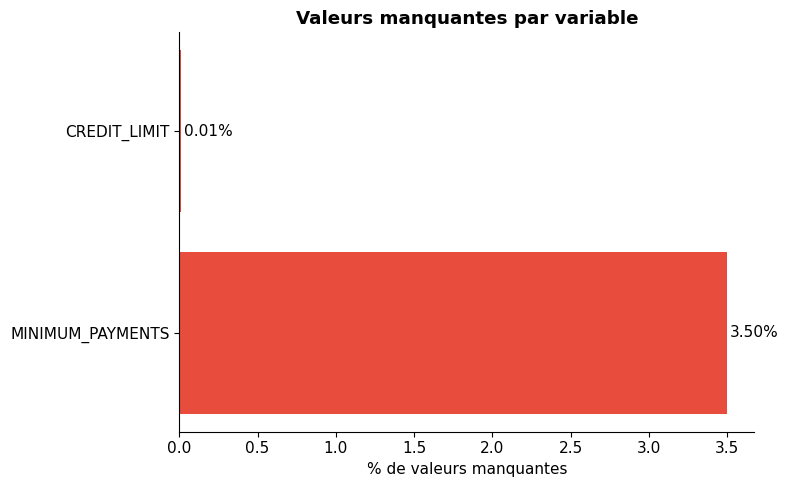

In [4]:
missing = df_num.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(" Variables avec valeurs manquantes :")
for col, n in missing.items():
    pct = n / len(df) * 100
    print(f"  • {col:<25} : {n:>4} valeurs manquantes ({pct:.2f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=FIGSIZE_S)
ax.barh(missing.index, missing.values / len(df) * 100, color="#e74c3c")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par variable", fontweight='bold')
for i, v in enumerate(missing.values / len(df) * 100):
    ax.text(v + 0.02, i, f"{v:.2f}%", va='center')
plt.tight_layout()
plt.show()


### 2.3 Distributions Univariées

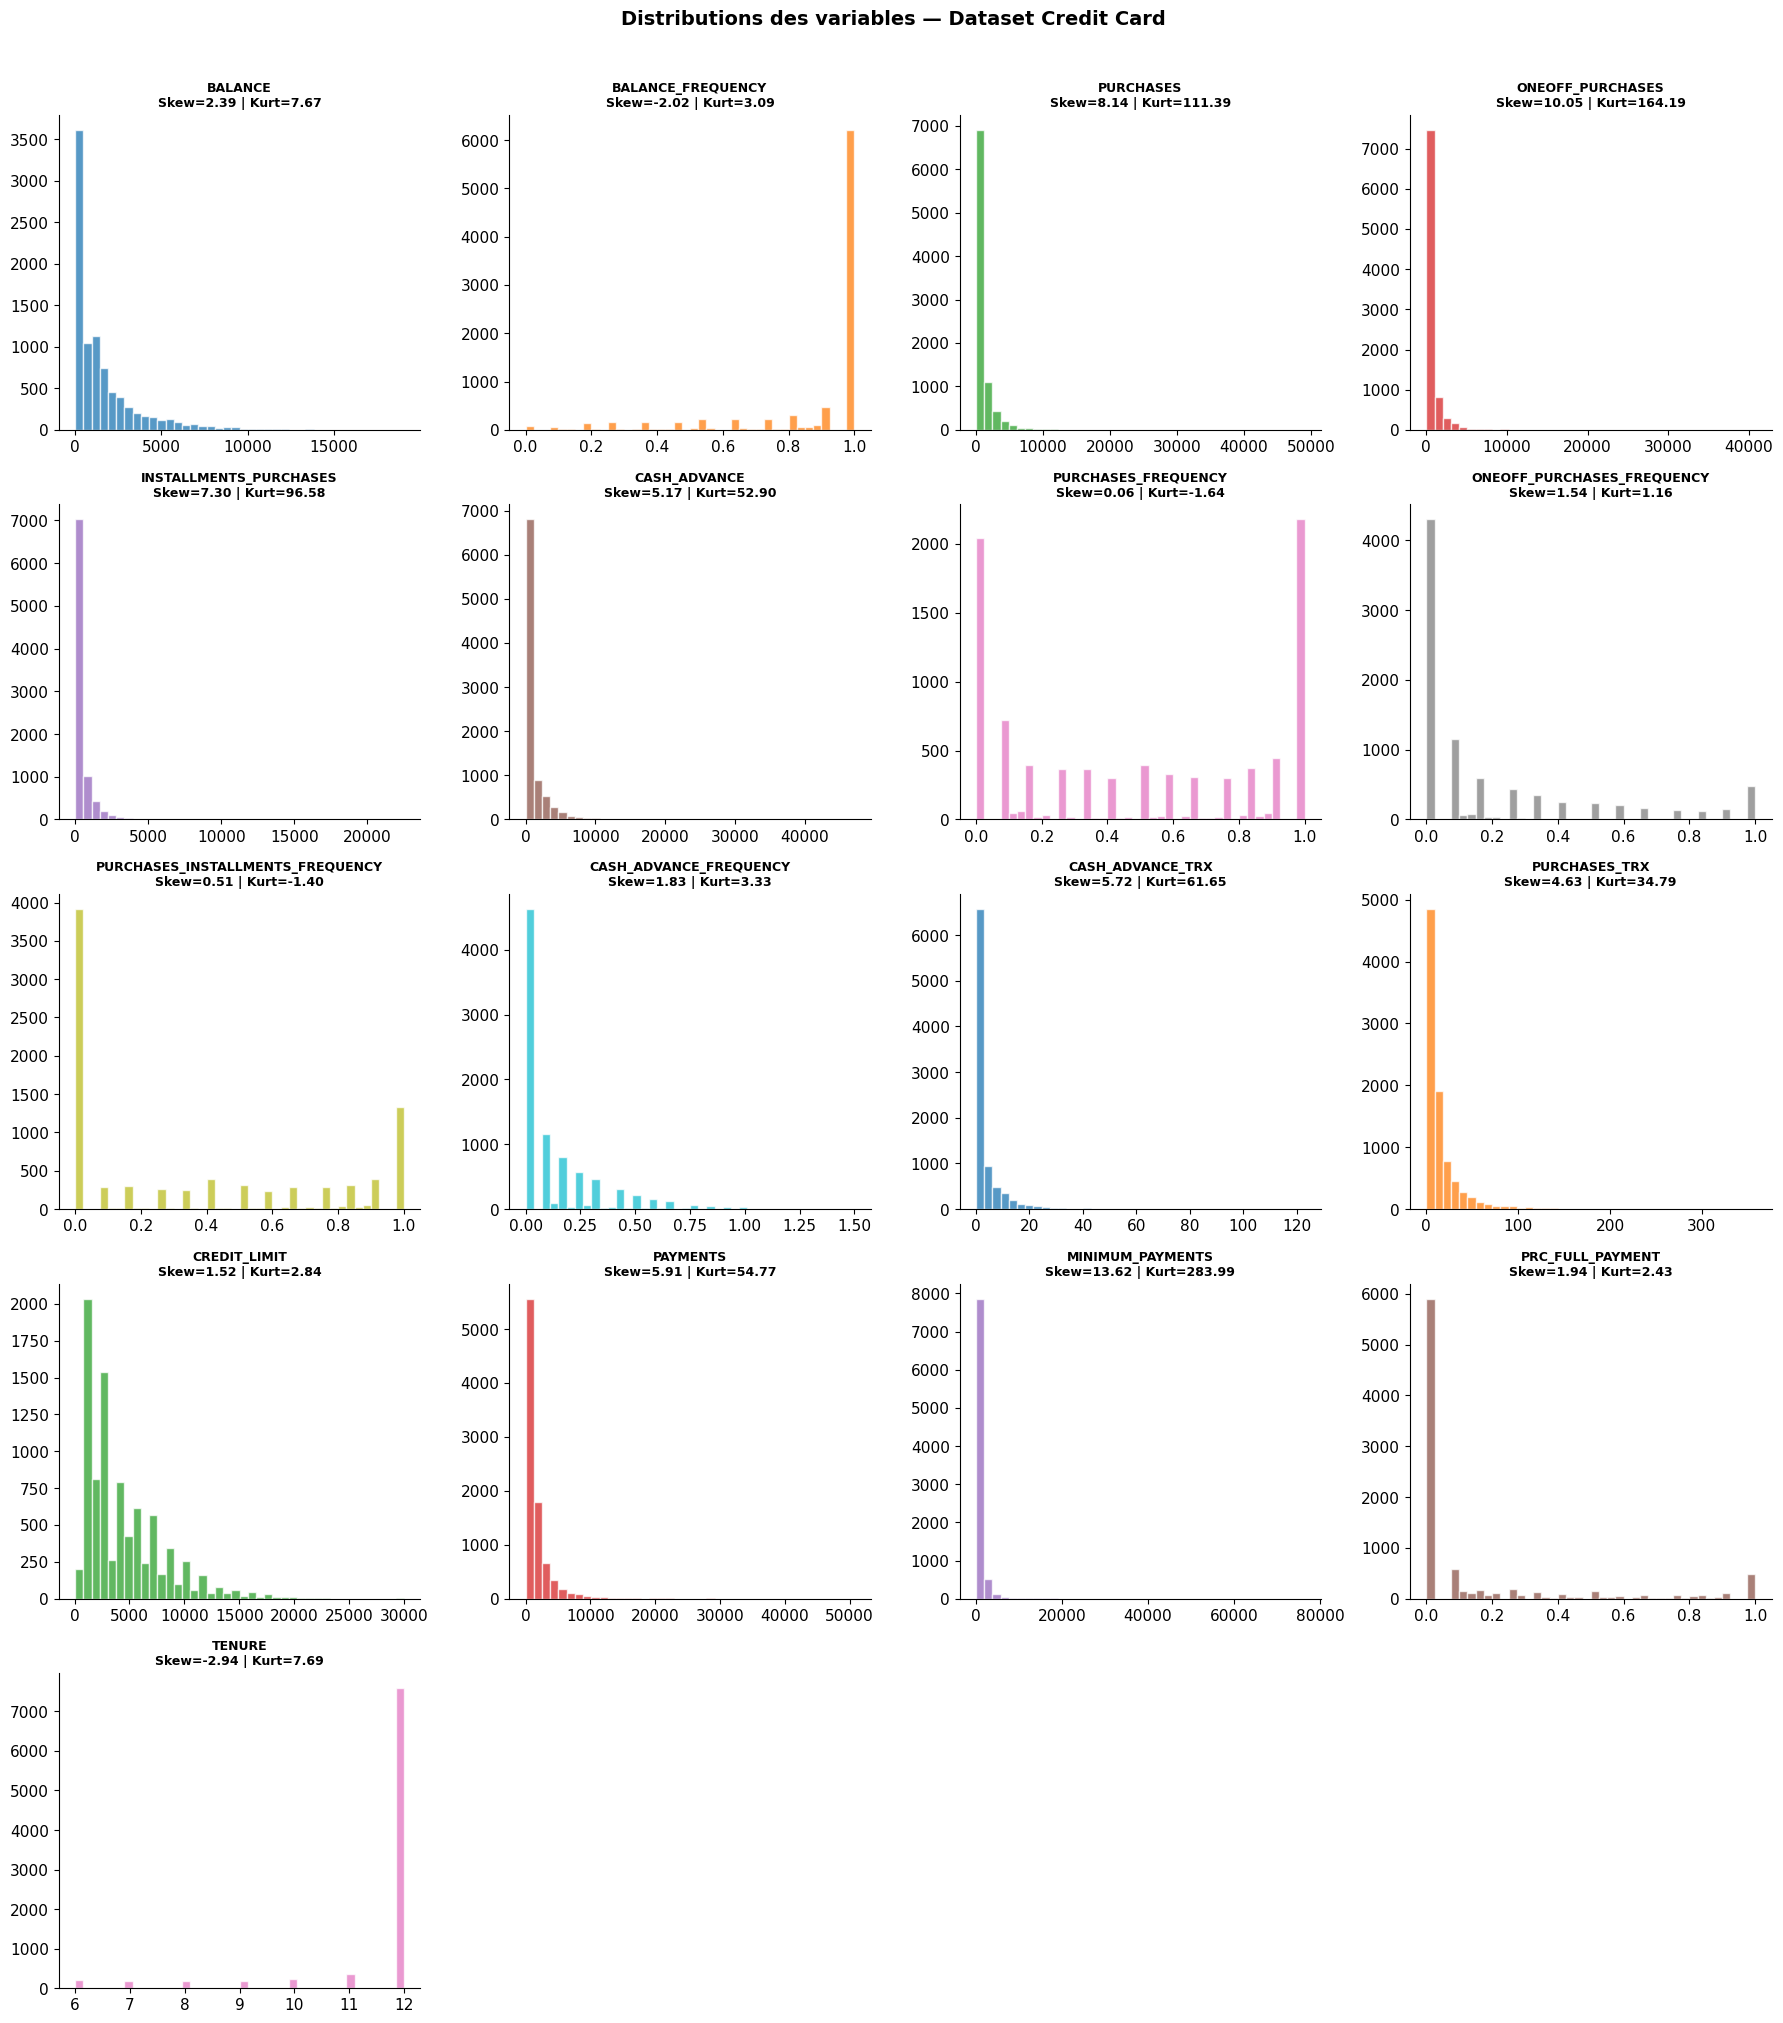

In [5]:
import math

n_cols = 4
n_rows = math.ceil(len(df_num.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    ax = axes[i]
    data = df_num[col].dropna()
    ax.hist(data, bins=40, color=PALETTE[i % 10], alpha=0.75, edgecolor='white')
    ax.set_title(f"{col}\nSkew={data.skew():.2f} | Kurt={data.kurtosis():.2f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("")
    
# Masquer les axes inutilisés
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions des variables — Dataset Credit Card", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.4 Analyse des Outliers (IQR + Boxplots)

 Nombre d'outliers détectés (méthode IQR × 1.5) :


,Outliers_bas,Outliers_haut,Total,% du dataset
BALANCE_FREQUENCY,1493,0,1493,16.68
PRC_FULL_PAYMENT,0,1474,1474,16.47
TENURE,1366,0,1366,15.26
CASH_ADVANCE,0,1030,1030,11.51
ONEOFF_PURCHASES,0,1013,1013,11.32
INSTALLMENTS_PURCHASES,0,867,867,9.69
MINIMUM_PAYMENTS,0,841,841,9.40
PAYMENTS,0,808,808,9.03
PURCHASES,0,808,808,9.03
CASH_ADVANCE_TRX,0,804,804,8.98


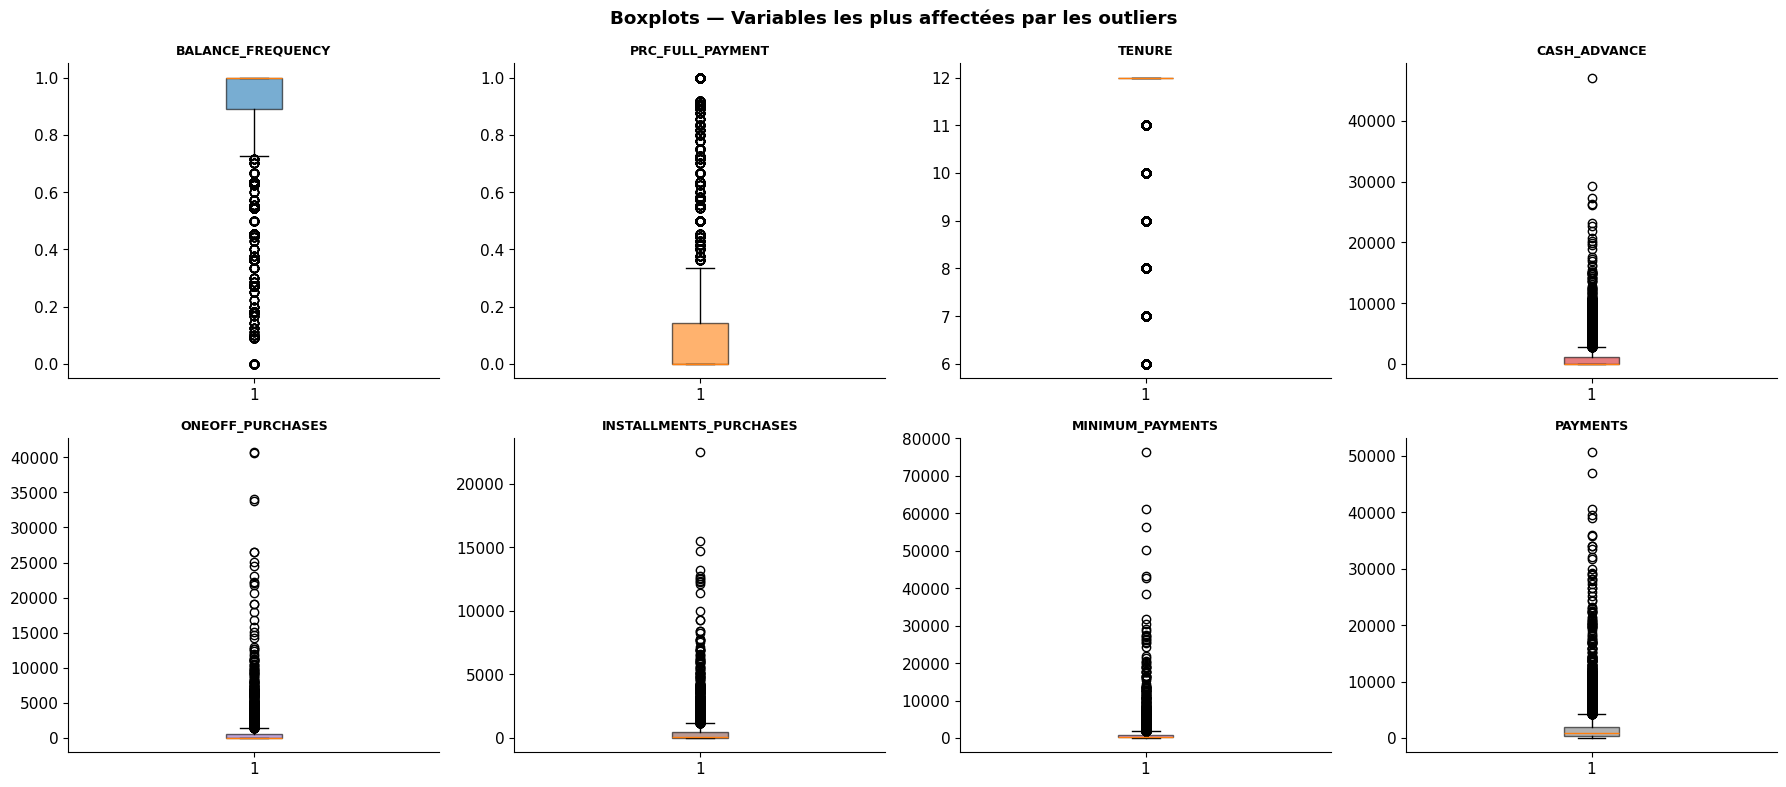

In [6]:
# Détection outliers par méthode IQR
Q1  = df_num.quantile(0.25)
Q3  = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_low  = (df_num < (Q1 - 1.5 * IQR)).sum()
outliers_high = (df_num > (Q3 + 1.5 * IQR)).sum()
outliers_total = outliers_low + outliers_high

print(" Nombre d'outliers détectés (méthode IQR × 1.5) :")
outlier_df = pd.DataFrame({
    "Outliers_bas" : outliers_low,
    "Outliers_haut": outliers_high,
    "Total"        : outliers_total,
    "% du dataset" : (outliers_total / len(df) * 100).round(2)
}).sort_values("Total", ascending=False)
display(outlier_df[outlier_df["Total"] > 0])

# Boxplots des variables les plus touchées
top_outlier_cols = outlier_df.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(top_outlier_cols):
    axes[i].boxplot(df_num[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i], alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel("")
plt.suptitle("Boxplots — Variables les plus affectées par les outliers", fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 Matrice de Corrélation

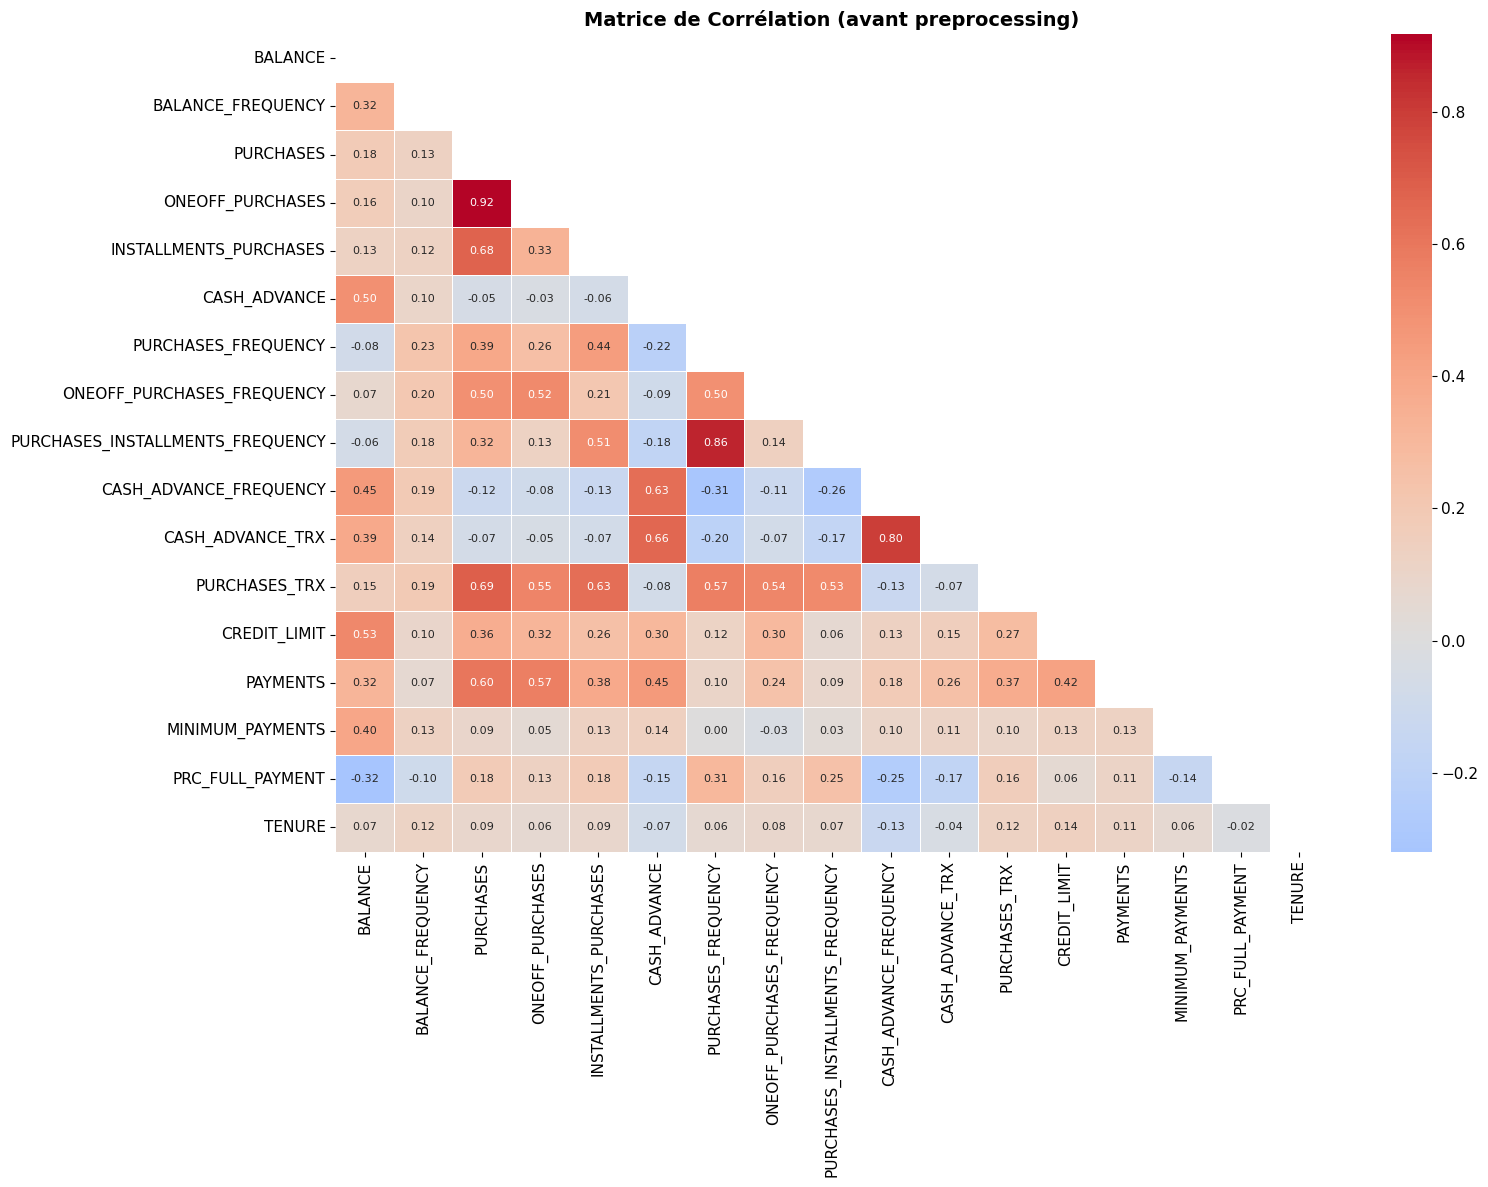


 Top 10 corrélations les plus fortes (|r| > 0.6) :
  • ONEOFF_PURCHASES                    ↔ PURCHASES                           : r = +0.917
  • PURCHASES_INSTALLMENTS_FREQUENCY    ↔ PURCHASES_FREQUENCY                 : r = +0.863
  • CASH_ADVANCE_TRX                    ↔ CASH_ADVANCE_FREQUENCY              : r = +0.800
  • PURCHASES_TRX                       ↔ PURCHASES                           : r = +0.690
  • INSTALLMENTS_PURCHASES              ↔ PURCHASES                           : r = +0.680
  • CASH_ADVANCE_TRX                    ↔ CASH_ADVANCE                        : r = +0.656
  • CASH_ADVANCE_FREQUENCY              ↔ CASH_ADVANCE                        : r = +0.629
  • PURCHASES_TRX                       ↔ INSTALLMENTS_PURCHASES              : r = +0.628
  • PAYMENTS                            ↔ PURCHASES                           : r = +0.603


In [7]:
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # afficher triangle inférieur seulement
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Matrice de Corrélation (avant preprocessing)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Top corrélations absolues
print("\n Top 10 corrélations les plus fortes (|r| > 0.6) :")
corr_pairs = (corr.abs()
               .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
               .stack()
               .sort_values(ascending=False))
for (v1, v2), r in corr_pairs[corr_pairs > 0.6].items():
    r_signed = corr.loc[v1, v2]
    print(f"  • {v1:<35} ↔ {v2:<35} : r = {r_signed:+.3f}")


### 2.6 Variance Inflation Factor (VIF)

Le VIF mesure la multicolinéarité formellement. Un VIF > 10 indique une redondance forte et justifie la suppression ou la transformation de la variable.


📊 Variance Inflation Factor (VIF) — Avant preprocessing :
   VIF > 10 : multicolinéarité forte → candidat à la suppression/transformation
   VIF < 5  : acceptable



,Variable,VIF
2,PURCHASES,58509.81
3,ONEOFF_PURCHASES,32612.47
4,INSTALLMENTS_PURCHASES,10357.27
6,PURCHASES_FREQUENCY,26.52
1,BALANCE_FREQUENCY,23.08
16,TENURE,20.64
8,PURCHASES_INSTALLMENTS_FREQUENCY,17.21
7,ONEOFF_PURCHASES_FREQUENCY,5.69
9,CASH_ADVANCE_FREQUENCY,4.97
12,CREDIT_LIMIT,4.70


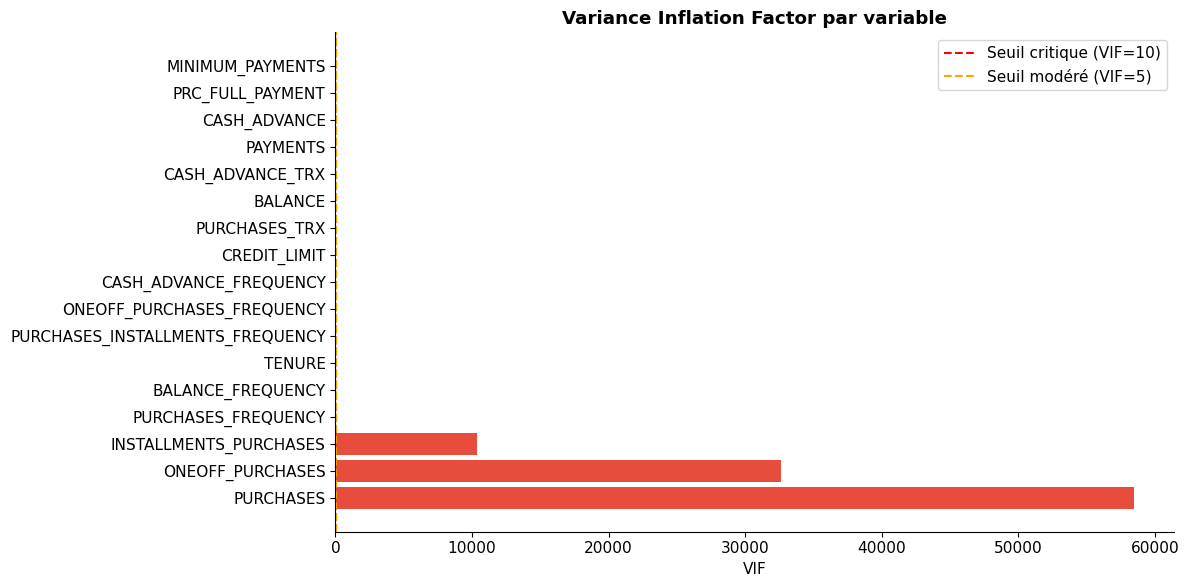

In [8]:
df_vif = df_num.dropna()

vif_data = pd.DataFrame({
    "Variable": df_vif.columns,
    "VIF"     : [variance_inflation_factor(df_vif.values, i)
                 for i in range(df_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("📊 Variance Inflation Factor (VIF) — Avant preprocessing :")
print("   VIF > 10 : multicolinéarité forte → candidat à la suppression/transformation")
print("   VIF < 5  : acceptable")
print()
display(vif_data.round(2))

fig, ax = plt.subplots(figsize=FIGSIZE_M)
colors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71"
          for v in vif_data["VIF"]]
ax.barh(vif_data["Variable"], vif_data["VIF"], color=colors)
ax.axvline(10, color='red', linestyle='--', label='Seuil critique (VIF=10)')
ax.axvline(5,  color='orange', linestyle='--', label='Seuil modéré (VIF=5)')
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor par variable", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 3.  Preprocessing

### 3.1 Suppression de l'identifiant client

In [9]:
# CUST_ID est un identifiant sans valeur prédictive — à supprimer AVANT tout traitement
df = df.drop(columns=["CUST_ID"])
print(f" CUST_ID supprimé — Shape : {df.shape}")


 CUST_ID supprimé — Shape : (8950, 17)


### 3.2 Imputation des valeurs manquantes

In [10]:
# Stratégie : médiane (robuste aux outliers, contrairement à la moyenne)
cols_to_impute = ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]

for col in cols_to_impute:
    median_val = df[col].median()
    n_missing  = df[col].isnull().sum()
    df[col]    = df[col].fillna(median_val)
    print(f"   {col:<25} : {n_missing} valeurs imputées par la médiane ({median_val:,.2f})")

print(f"\n Valeurs manquantes restantes : {df.isnull().sum().sum()}")


   CREDIT_LIMIT              : 1 valeurs imputées par la médiane (3,000.00)
   MINIMUM_PAYMENTS          : 313 valeurs imputées par la médiane (312.34)

 Valeurs manquantes restantes : 0


### 3.3 Traitement des Outliers — Winsorization

**Méthode :** Winsorization aux percentiles 1% et 99%.  
**Justification :** ISODATA (comme K-Means) calcule des centroïdes par moyenne — les outliers extrêmes biaisent fortement ces centroïdes. La Winsorization préserve les observations tout en écrêtant les valeurs aberrantes.


In [11]:
df_clean = df.copy()

winsorization_log = {}
for col in df_clean.columns:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    n_clipped = ((df_clean[col] < p01) | (df_clean[col] > p99)).sum()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    winsorization_log[col] = n_clipped

print(" Winsorization appliquée (P1–P99) :")
for col, n in winsorization_log.items():
    if n > 0:
        print(f"  • {col:<35} : {n:>4} valeurs écrêtées ({n/len(df)*100:.2f}%)")

print(f"\n Dataset nettoyé — Shape : {df_clean.shape}")


 Winsorization appliquée (P1–P99) :
  • BALANCE                             :  180 valeurs écrêtées (2.01%)
  • BALANCE_FREQUENCY                   :   80 valeurs écrêtées (0.89%)
  • PURCHASES                           :   90 valeurs écrêtées (1.01%)
  • ONEOFF_PURCHASES                    :   90 valeurs écrêtées (1.01%)
  • INSTALLMENTS_PURCHASES              :   90 valeurs écrêtées (1.01%)
  • CASH_ADVANCE                        :   90 valeurs écrêtées (1.01%)
  • CASH_ADVANCE_FREQUENCY              :   77 valeurs écrêtées (0.86%)
  • CASH_ADVANCE_TRX                    :   89 valeurs écrêtées (0.99%)
  • PURCHASES_TRX                       :   90 valeurs écrêtées (1.01%)
  • CREDIT_LIMIT                        :  110 valeurs écrêtées (1.23%)
  • PAYMENTS                            :   90 valeurs écrêtées (1.01%)
  • MINIMUM_PAYMENTS                    :  180 valeurs écrêtées (2.01%)

 Dataset nettoyé — Shape : (8950, 17)


## 4.  Feature Engineering

Création de variables comportementales dérivées qui capturent mieux les habitudes financières des clients.  
**Important :** Le feature engineering est effectué sur les données brutes (avant scaling) pour préserver l'interprétabilité des ratios.


In [12]:
df_fe = df_clean.copy()

# ── Feature 1 : Part des achats one-off dans les achats totaux ───────────────
df_fe["TOTAL_ONEOFF_RATIO"] = df_fe["ONEOFF_PURCHASES"] / (df_fe["PURCHASES"] + 1e-6)

# ── Feature 2 : Dominance des achats échelonnés sur les achats classiques ───
df_fe["INSTALLMENT_DOMINANCE"] = (
    df_fe["PURCHASES_INSTALLMENTS_FREQUENCY"] /
    (df_fe["PURCHASES_FREQUENCY"] + 1e-6)
)

# ── Feature 3 : Intensité d'utilisation du cash advance ─────────────────────
df_fe["CASH_ADVANCE_INTENSITY"] = (
    df_fe["CASH_ADVANCE"] / (df_fe["CASH_ADVANCE_FREQUENCY"] + 1e-6)
)

# ── Feature 4 : Taux de remboursement (solvabilité) ─────────────────────────
df_fe["PAYMENT_TO_CREDIT_RATIO"] = df_fe["PAYMENTS"] / (df_fe["CREDIT_LIMIT"] + 1e-6)

# ── Feature 5 : Discipline de remboursement ──────────────────────────────────
df_fe["PAYMENT_TO_BALANCE_RATIO"] = df_fe["PAYMENTS"] / (df_fe["BALANCE"] + 1e-6)

print("Features créées :")
new_features = ["TOTAL_ONEOFF_RATIO", "INSTALLMENT_DOMINANCE",
                "CASH_ADVANCE_INTENSITY", "PAYMENT_TO_CREDIT_RATIO",
                "PAYMENT_TO_BALANCE_RATIO"]
for f in new_features:
    print(f"  • {f:<35} : min={df_fe[f].min():.3f} | median={df_fe[f].median():.3f} | max={df_fe[f].max():.3f}")


Features créées :
  • TOTAL_ONEOFF_RATIO                  : min=0.000 | median=0.112 | max=1.804
  • INSTALLMENT_DOMINANCE               : min=0.000 | median=0.500 | max=166667.000
  • CASH_ADVANCE_INTENSITY              : min=0.000 | median=0.000 | max=115057.040
  • PAYMENT_TO_CREDIT_RATIO             : min=0.000 | median=0.250 | max=15.140
  • PAYMENT_TO_BALANCE_RATIO            : min=0.000 | median=1.408 | max=209038.144


### 4.1 Interprétation des Features Créées

| Feature | Valeur ≈ 0 | Valeur ≈ 0.5 | Valeur ≈ 1+ |
|---------|-----------|-------------|------------|
| `TOTAL_ONEOFF_RATIO` | Achats principalement échelonnés | Mélange équilibré | Achats quasi-exclusivement directs |
| `INSTALLMENT_DOMINANCE` | Achats directs dominent | Équilibre | Forte utilisation du crédit échelonné |
| `CASH_ADVANCE_INTENSITY` | Faible utilisation cash | — | Dépendance massive aux avances cash |
| `PAYMENT_TO_CREDIT_RATIO` | Faible remboursement vs limite | — | Client très solvable |
| `PAYMENT_TO_BALANCE_RATIO` | Solde non remboursé | — | Remboursement rapide du solde |


### 4.2 Suppression des Variables Redondantes (guidée par VIF + Corrélation)

In [13]:
# Variables supprimées car remplacées par les features engineerées
# ou fortement corrélées (r > 0.85) avec d'autres variables conservées
cols_to_drop = [
    "ONEOFF_PURCHASES",                   # → capturé par TOTAL_ONEOFF_RATIO
    "PURCHASES_INSTALLMENTS_FREQUENCY",   # → capturé par INSTALLMENT_DOMINANCE
    "CASH_ADVANCE_TRX",                   # → fortement corrélé avec CASH_ADVANCE_FREQUENCY
    "CASH_ADVANCE_FREQUENCY",             # → capturé par CASH_ADVANCE_INTENSITY
    "PURCHASES_FREQUENCY",                # → inclus dans INSTALLMENT_DOMINANCE
]

df_fe = df_fe.drop(columns=cols_to_drop)
print(f" {len(cols_to_drop)} colonnes supprimées")
print(f" Shape après feature engineering : {df_fe.shape}")
print(f"\n Features finales ({df_fe.shape[1]}) :")
for i, col in enumerate(df_fe.columns, 1):
    print(f"  {i:2d}. {col}")


 5 colonnes supprimées
 Shape après feature engineering : (8950, 17)

 Features finales (17) :
   1. BALANCE
   2. BALANCE_FREQUENCY
   3. PURCHASES
   4. INSTALLMENTS_PURCHASES
   5. CASH_ADVANCE
   6. ONEOFF_PURCHASES_FREQUENCY
   7. PURCHASES_TRX
   8. CREDIT_LIMIT
   9. PAYMENTS
  10. MINIMUM_PAYMENTS
  11. PRC_FULL_PAYMENT
  12. TENURE
  13. TOTAL_ONEOFF_RATIO
  14. INSTALLMENT_DOMINANCE
  15. CASH_ADVANCE_INTENSITY
  16. PAYMENT_TO_CREDIT_RATIO
  17. PAYMENT_TO_BALANCE_RATIO


## 5.  Normalisation & Réduction de Dimension

### Pourquoi normaliser ?
ISODATA (comme K-Means) utilise la **distance euclidienne**. Sans normalisation, les variables à grande amplitude (ex: PURCHASES en milliers) dominent artificiellement celles en faible amplitude (ex: PRC_FULL_PAYMENT ∈ [0,1]).

**StandardScaler :** Centre (μ=0) et réduit (σ=1) chaque variable → distances euclidiennes équitables.


In [14]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fe)
X_scaled = pd.DataFrame(X_scaled, columns=df_fe.columns, index=df_fe.index)

print(f" Normalisation StandardScaler appliquée")
print(f"   Vérification μ ≈ 0 : {X_scaled.mean().abs().max():.2e}")
print(f"   Vérification σ ≈ 1 : {X_scaled.std().max():.4f}")
print(f"\n Shape finale : {X_scaled.shape}")


 Normalisation StandardScaler appliquée
   Vérification μ ≈ 0 : 2.79e-16
   Vérification σ ≈ 1 : 1.0001

 Shape finale : (8950, 17)


### 5.1 PCA — Analyse en Composantes Principales

📊 PCA — Variance expliquée cumulée :
   • 11 composantes → 92.3% de variance
   • 13 composantes → 95.6% de variance


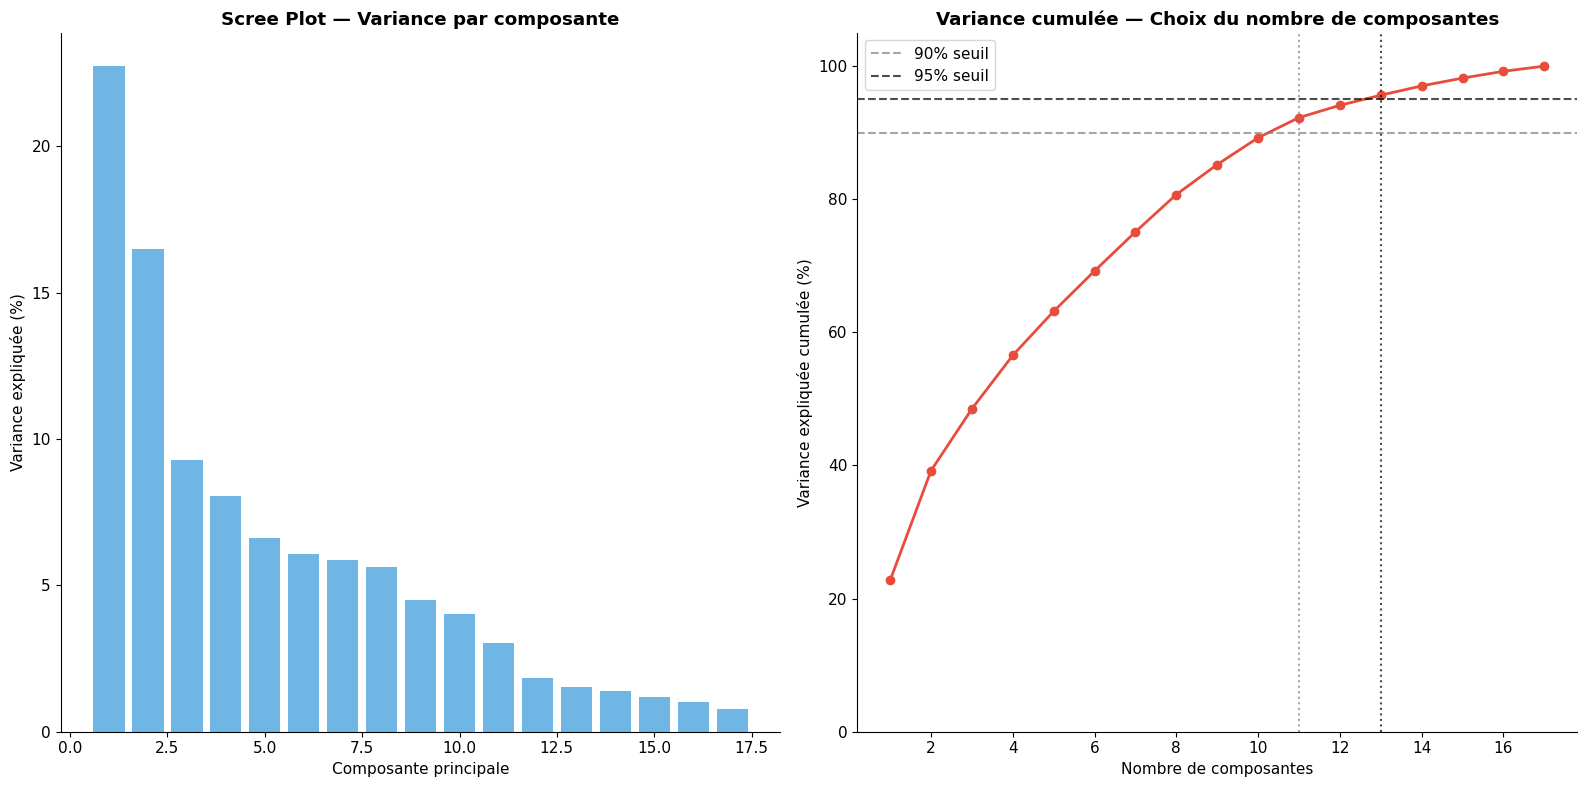


 Décision : on retient 11 composantes (≥90% de variance) pour la visualisation.
   Le clustering sera effectué sur les 17 features scalées (pas les composantes PCA),
   la PCA est utilisée uniquement pour la visualisation 2D.


In [15]:
pca_full  = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative    = np.cumsum(explained_var)

# Trouver le nombre de composantes pour 90% et 95% de variance
n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

print(f"📊 PCA — Variance expliquée cumulée :")
print(f"   • {n_90} composantes → {cumulative[n_90-1]*100:.1f}% de variance")
print(f"   • {n_95} composantes → {cumulative[n_95-1]*100:.1f}% de variance")

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_L)

# Scree plot
ax = axes[0]
ax.bar(range(1, len(explained_var)+1), explained_var*100, color="#3498db", alpha=0.7)
ax.set_xlabel("Composante principale")
ax.set_ylabel("Variance expliquée (%)")
ax.set_title("Scree Plot — Variance par composante", fontweight='bold')

# Variance cumulée
ax = axes[1]
ax.plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color="#e74c3c", linewidth=2)
ax.axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% seuil')
ax.axhline(95, color='black', linestyle='--', alpha=0.7, label='95% seuil')
ax.axvline(n_90, color='gray', linestyle=':', alpha=0.7)
ax.axvline(n_95, color='black', linestyle=':', alpha=0.7)
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée cumulée (%)")
ax.set_title("Variance cumulée — Choix du nombre de composantes", fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
print(f"\n Décision : on retient {n_90} composantes (≥90% de variance) pour la visualisation.")
print(f"   Le clustering sera effectué sur les {X_scaled.shape[1]} features scalées (pas les composantes PCA),")
print(f"   la PCA est utilisée uniquement pour la visualisation 2D.")


 PCA 2D — Variance expliquée totale : 39.2%
   PC1 : 22.7%
   PC2 : 16.5%


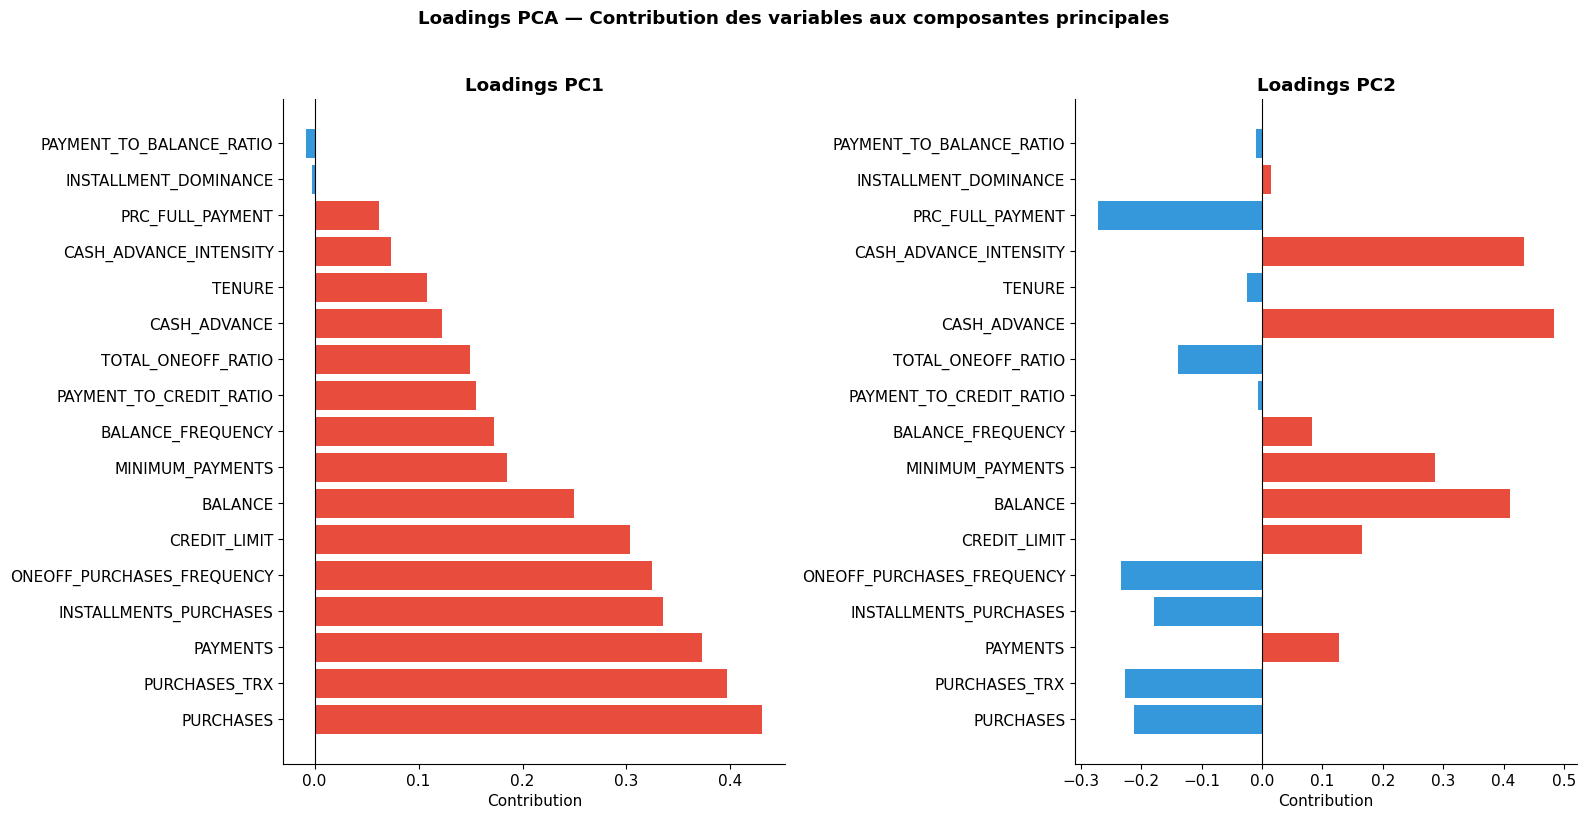

In [16]:
# PCA 2D pour visualisation
pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca_2d.fit_transform(X_scaled)

print(f" PCA 2D — Variance expliquée totale : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   PC1 : {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"   PC2 : {pca_2d.explained_variance_ratio_[1]*100:.1f}%")

# Loadings plot (contribution des variables aux composantes)
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X_scaled.columns,
    columns=["PC1", "PC2"]
).sort_values("PC1", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_L)

for i, pc in enumerate(["PC1", "PC2"]):
    ax = axes[i]
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in loadings[pc]]
    ax.barh(loadings.index, loadings[pc], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"Loadings {pc}", fontweight='bold')
    ax.set_xlabel("Contribution")

plt.suptitle("Loadings PCA — Contribution des variables aux composantes principales",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6.  Sélection du Nombre Optimal de Clusters (K)

Avant toute modélisation, on détermine K de façon rigoureuse par trois méthodes complémentaires :

1. **Elbow Method** : minimiser l'inertie intra-cluster
2. **Silhouette Score** : mesure de cohésion et séparation ([-1, 1], maximiser)
3. **Davies-Bouldin Index** : ratio intra/inter-cluster (positif, minimiser)


Métriques de sélection de K :


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,130246.5980,0.3172,1.9851,1504.7853
1,3,115043.8046,0.2763,1.6347,1442.8891
2,4,105952.0003,0.1621,1.7558,1300.2364
3,5,99602.9676,0.1767,1.6180,1179.7671
4,6,94100.5653,0.1494,1.4978,1103.4901
5,7,85745.5014,0.1829,1.3630,1154.2988
6,8,82032.1667,0.1787,1.1677,1091.8951
7,9,76502.3677,0.1820,1.3202,1105.1386
8,10,71699.7926,0.1779,1.3570,1114.5643
9,11,68032.9974,0.1875,1.3079,1105.2317


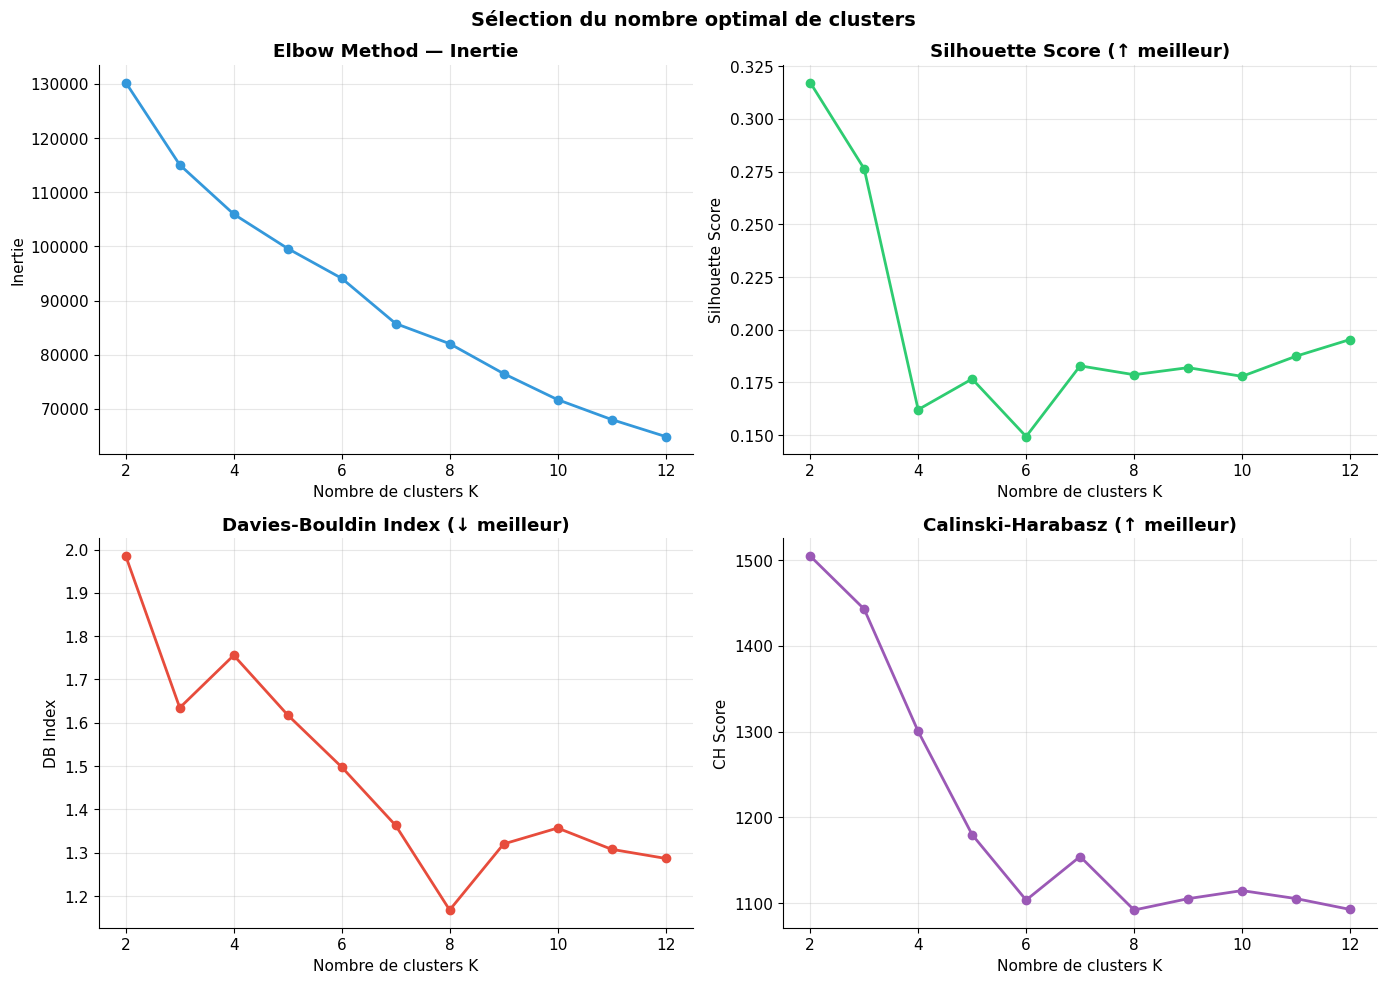


 K optimal recommandé : K = 2
   Silhouette Score max  : 0.3172
   DB Index correspondant: 1.9851


In [17]:
K_RANGE    = range(2, 13)
inertia    = []
silhouette = []
davies_bouldin = []
calinski   = []

X_cluster = X_scaled.values  # array numpy pour sklearn

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels_k))
    davies_bouldin.append(davies_bouldin_score(X_cluster, labels_k))
    calinski.append(calinski_harabasz_score(X_cluster, labels_k))

# Résultats
results_df = pd.DataFrame({
    "K"              : list(K_RANGE),
    "Inertia"        : inertia,
    "Silhouette"     : silhouette,
    "Davies-Bouldin" : davies_bouldin,
    "Calinski-Harabasz": calinski
})

print("Métriques de sélection de K :")
display(results_df.round(4))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(list(K_RANGE), inertia, 'o-', color="#3498db", linewidth=2)
axes[0,0].set_title("Elbow Method — Inertie", fontweight='bold')
axes[0,0].set_xlabel("Nombre de clusters K")
axes[0,0].set_ylabel("Inertie")

axes[0,1].plot(list(K_RANGE), silhouette, 'o-', color="#2ecc71", linewidth=2)
axes[0,1].set_title("Silhouette Score (↑ meilleur)", fontweight='bold')
axes[0,1].set_xlabel("Nombre de clusters K")
axes[0,1].set_ylabel("Silhouette Score")

axes[1,0].plot(list(K_RANGE), davies_bouldin, 'o-', color="#e74c3c", linewidth=2)
axes[1,0].set_title("Davies-Bouldin Index (↓ meilleur)", fontweight='bold')
axes[1,0].set_xlabel("Nombre de clusters K")
axes[1,0].set_ylabel("DB Index")

axes[1,1].plot(list(K_RANGE), calinski, 'o-', color="#9b59b6", linewidth=2)
axes[1,1].set_title("Calinski-Harabasz (↑ meilleur)", fontweight='bold')
axes[1,1].set_xlabel("Nombre de clusters K")
axes[1,1].set_ylabel("CH Score")

for ax in axes.flatten():
    ax.grid(alpha=0.3)

plt.suptitle("Sélection du nombre optimal de clusters", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Recommandation
K_optimal = int(results_df.loc[results_df["Silhouette"].idxmax(), "K"])
print(f"\n K optimal recommandé : K = {K_optimal}")
print(f"   Silhouette Score max  : {results_df['Silhouette'].max():.4f}")
print(f"   DB Index correspondant: {results_df.loc[results_df['Silhouette'].idxmax(), 'Davies-Bouldin']:.4f}")


## 7.  Modèle Baseline — K-Means

K-Means sert de **référence (baseline)** pour évaluer la valeur ajoutée d'ISODATA.  
On utilise `K_optimal` déterminé à l'étape précédente.


In [18]:
K_FINAL = K_optimal  # ou choisir manuellement selon l'elbow

km_model = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
km_labels = km_model.fit_predict(X_cluster)

# Métriques
km_silhouette = silhouette_score(X_cluster, km_labels)
km_db         = davies_bouldin_score(X_cluster, km_labels)
km_ch         = calinski_harabasz_score(X_cluster, km_labels)

print(f" K-Means — K={K_FINAL}")
print(f"   Silhouette Score     : {km_silhouette:.4f}")
print(f"   Davies-Bouldin Index : {km_db:.4f}")
print(f"   Calinski-Harabasz    : {km_ch:.4f}")
print(f"   Inertie              : {km_model.inertia_:,.2f}")

# Distribution des clusters
km_sizes = pd.Series(km_labels).value_counts().sort_index()
print(f"\n📊 Distribution des clusters K-Means :")
for k, n in km_sizes.items():
    print(f"   Cluster {k} : {n:>5} clients ({n/len(km_labels)*100:.1f}%)")


 K-Means — K=2
   Silhouette Score     : 0.3172
   Davies-Bouldin Index : 1.9851
   Calinski-Harabasz    : 1504.7853
   Inertie              : 130,246.60

📊 Distribution des clusters K-Means :
   Cluster 0 :  7068 clients (79.0%)
   Cluster 1 :  1882 clients (21.0%)


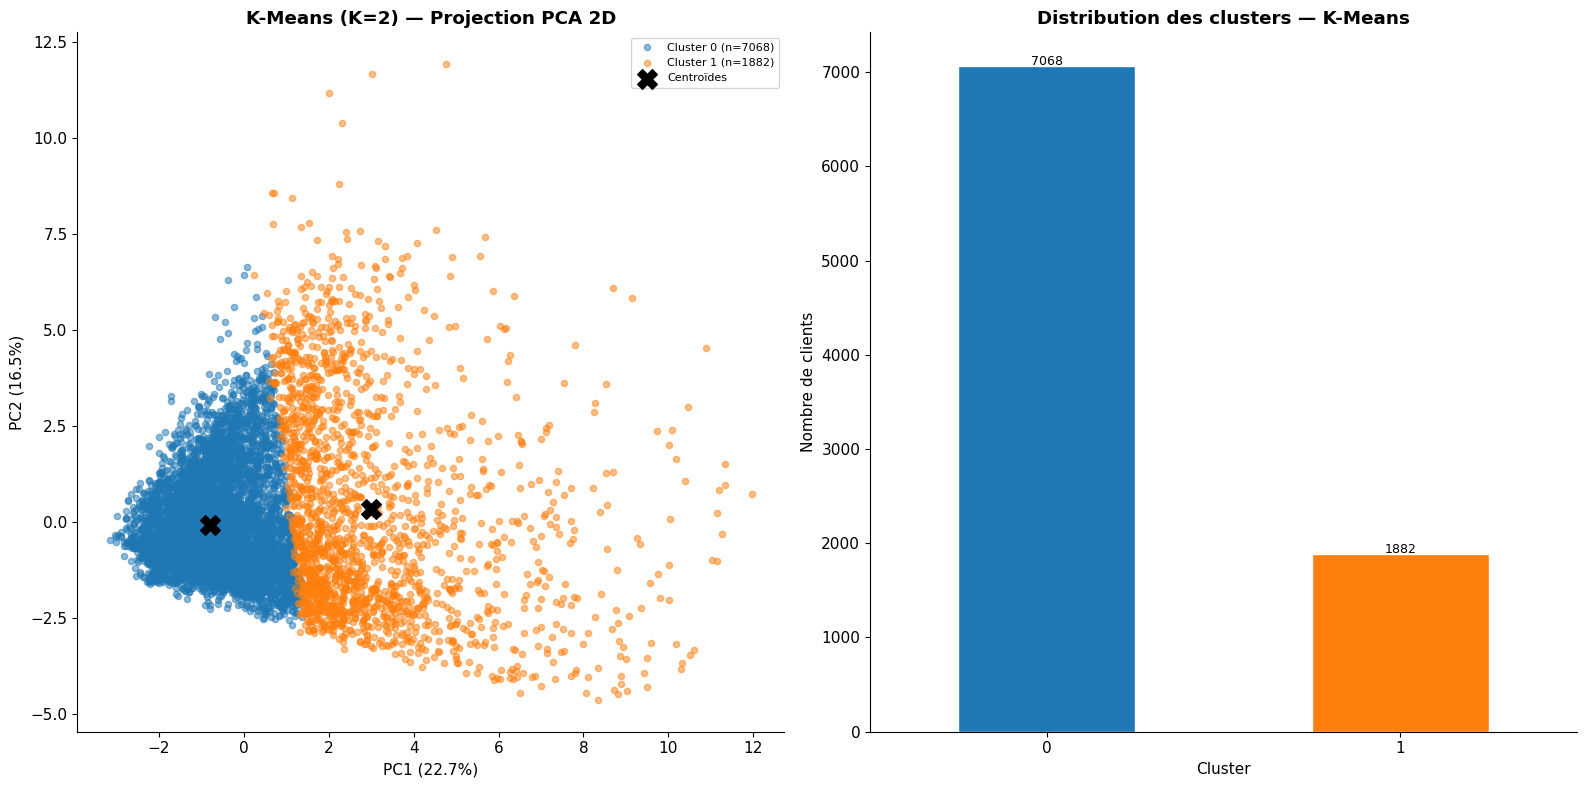

In [19]:
# Visualisation K-Means sur PCA 2D
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_L)

ax = axes[0]
for k in range(K_FINAL):
    mask = km_labels == k
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               c=[PALETTE[k]], label=f"Cluster {k} (n={mask.sum()})",
               alpha=0.5, s=20)
centers_pca = pca_2d.transform(km_model.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200,
           c='black', zorder=5, label="Centroïdes")
ax.set_title(f"K-Means (K={K_FINAL}) — Projection PCA 2D", fontweight='bold')
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(fontsize=8)

# Taille des clusters
ax = axes[1]
km_sizes.plot(kind='bar', ax=ax, color=[PALETTE[k] for k in km_sizes.index],
              edgecolor='white')
ax.set_title("Distribution des clusters — K-Means", fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Nombre de clients")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{int(bar.get_height())}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 8.  Modèle Principal — ISODATA

### Pourquoi ISODATA plutôt que K-Means ?

ISODATA (*Iterative Self-Organizing Data Analysis Technique*) est une extension adaptative de K-Means qui résout ses limites principales :

| Limitation K-Means | Solution ISODATA |
|---|---|
| K fixé a priori | K **dynamique** : évolue par split et merge |
| Ne gère pas les clusters trop dispersés | **Split** : un cluster trop hétérogène est divisé |
| Ne gère pas les clusters trop proches | **Merge** : deux clusters trop proches sont fusionnés |
| Sensible à l'initialisation | Démarre avec K-Means puis s'adapte |

### Paramètres ISODATA

| Paramètre | Rôle | Valeur choisie | Justification |
|---|---|---|---|
| `k_init` | Nombre initial de clusters | K_optimal | Basé sur l'analyse Silhouette |
| `max_iter` | Itérations max | 20 | Convergence typique en 10-15 iter |
| `split_std_threshold` | Seuil d'écart-type pour split | 1.0 | Sur données standardisées (σ=1) |
| `merge_dist_threshold` | Distance max pour merge | 2.0 | ~2σ sur données standardisées |
| `min_cluster_size` | Taille min d'un cluster | 10 | Éviter les micro-clusters |


In [20]:
class ISODATA:
    """
    Implémentation de l'algorithme ISODATA (Iterative Self-Organizing Data Analysis Technique).
    
    Paramètres
    ----------
    k_init              : int   — Nombre initial de clusters
    max_iter            : int   — Nombre maximum d'itérations
    split_std_threshold : float — Seuil d'écart-type pour déclencher un split
    merge_dist_threshold: float — Distance max entre centroïdes pour déclencher un merge
    min_cluster_size    : int   — Taille minimale d'un cluster (évite les micro-clusters)
    random_state        : int   — Reproductibilité
    verbose             : bool  — Affichage de la progression
    """
    
    def __init__(self, k_init=4, max_iter=20, split_std_threshold=1.0,
                 merge_dist_threshold=2.0, min_cluster_size=10,
                 random_state=42, verbose=True):
        self.k_init               = k_init
        self.max_iter             = max_iter
        self.split_std_threshold  = split_std_threshold
        self.merge_dist_threshold = merge_dist_threshold
        self.min_cluster_size     = min_cluster_size
        self.random_state         = random_state
        self.verbose              = verbose
        self.history_             = []  # suivi du nombre de clusters par itération

    def _assign(self, X, centroids):
        """Assigner chaque point au centroïde le plus proche."""
        return pairwise_distances_argmin(X, centroids)

    def _update_centroids(self, X, labels, centroids):
        """Recalculer les centroïdes comme moyenne des points du cluster."""
        new_centroids = []
        for k in range(len(centroids)):
            members = X[labels == k]
            if len(members) >= 1:
                new_centroids.append(members.mean(axis=0))
            else:
                new_centroids.append(centroids[k])  # garder le centroïde si cluster vide
        return np.array(new_centroids)

    def _split(self, X, labels, centroids):
        """
        Diviser les clusters trop dispersés.
        Critère : l'écart-type maximum sur une dimension dépasse split_std_threshold.
        Le split est effectué le long de la dimension de variance maximale.
        """
        new_centroids = []
        split_count   = 0

        for i, c in enumerate(centroids):
            members = X[labels == i]

            if len(members) < self.min_cluster_size * 2:
                # Cluster trop petit pour être splitté proprement
                new_centroids.append(c)
                continue

            std_per_dim = np.std(members, axis=0)
            max_std     = np.max(std_per_dim)
            split_axis  = np.argmax(std_per_dim)

            if max_std > self.split_std_threshold:
                # Déplacer les deux nouveaux centroïdes le long de l'axe de variance max
                delta         = np.zeros_like(c)
                delta[split_axis] = std_per_dim[split_axis] * 0.5
                new_centroids.append(c + delta)
                new_centroids.append(c - delta)
                split_count += 1
            else:
                new_centroids.append(c)

        return np.array(new_centroids), split_count

    def _merge(self, centroids):
        """
        Fusionner les clusters dont les centroïdes sont trop proches.
        Le nouveau centroïde est la moyenne des deux centroïdes fusionnés.
        """
        merged    = []
        used      = set()
        merge_count = 0

        for i in range(len(centroids)):
            if i in used:
                continue

            merged_centroid = centroids[i].copy()
            n_merged = 1

            for j in range(i + 1, len(centroids)):
                if j in used:
                    continue
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist < self.merge_dist_threshold:
                    # Fusionner en calculant la moyenne des centroïdes
                    merged_centroid = (merged_centroid * n_merged + centroids[j]) / (n_merged + 1)
                    n_merged += 1
                    used.add(j)
                    merge_count += 1

            merged.append(merged_centroid)

        return np.array(merged), merge_count

    def fit(self, X):
        """Entraîner le modèle ISODATA sur X."""
        X = np.array(X)
        np.random.seed(self.random_state)

        # Initialisation par K-Means pour de meilleurs centroïdes initiaux
        km_init  = KMeans(n_clusters=self.k_init, random_state=self.random_state, n_init=10)
        labels   = km_init.fit_predict(X)
        centroids = km_init.cluster_centers_.copy()

        if self.verbose:
            print(f" Initialisation K-Means — {len(centroids)} clusters")
            print(f"{'Iter':>4} | {'#Clusters':>10} | {'Splits':>7} | {'Merges':>7}")
            print("-" * 40)

        for iteration in range(self.max_iter):
            # 1) Assignation
            labels = self._assign(X, centroids)

            # 2) Mise à jour des centroïdes
            centroids = self._update_centroids(X, labels, centroids)

            # 3) Split des clusters trop dispersés
            centroids, n_splits = self._split(X, labels, centroids)

            # 4) Ré-assignation après split
            labels = self._assign(X, centroids)

            # 5) Merge des clusters trop proches
            centroids, n_merges = self._merge(centroids)

            # 6) Ré-assignation finale
            labels = self._assign(X, centroids)

            n_clusters = len(centroids)
            self.history_.append({
                "iteration": iteration + 1,
                "n_clusters": n_clusters,
                "n_splits"  : n_splits,
                "n_merges"  : n_merges
            })

            if self.verbose:
                print(f"{iteration+1:>4} | {n_clusters:>10} | {n_splits:>7} | {n_merges:>7}")

            # Critère d'arrêt : stabilité du nombre de clusters
            if iteration > 2 and n_splits == 0 and n_merges == 0:
                if self.verbose:
                    print(f"\n Convergence atteinte à l'itération {iteration+1}")
                break

        self.centroids_ = centroids
        self.labels_    = self._assign(X, centroids)
        self.n_clusters_= len(centroids)
        return self

    def predict(self, X):
        """Prédire les labels de nouveaux points."""
        X = np.array(X)
        return self._assign(X, self.centroids_)


In [21]:
# Entraînement ISODATA
print("=" * 60)
print("  ENTRAÎNEMENT ISODATA")
print("=" * 60)

iso_model = ISODATA(
    k_init               = K_FINAL,
    max_iter             = 30,
    split_std_threshold  = 1.0,   # données standardisées → σ=1 comme seuil naturel
    merge_dist_threshold = 2.0,   # ~2 écarts-types = clusters proches
    min_cluster_size     = 20,
    random_state         = RANDOM_STATE,
    verbose              = True
)

iso_model.fit(X_cluster)
iso_labels = iso_model.labels_

print(f"\n Résultats finaux :")
print(f"   Clusters initiaux (K-Means) : {K_FINAL}")
print(f"   Clusters finaux (ISODATA)   : {iso_model.n_clusters_}")


  ENTRAÎNEMENT ISODATA
 Initialisation K-Means — 2 clusters
Iter |  #Clusters |  Splits |  Merges
----------------------------------------
   1 |          2 |       2 |       2
   2 |          2 |       2 |       2
   3 |          2 |       2 |       2
   4 |          2 |       2 |       2
   5 |          2 |       2 |       2
   6 |          2 |       2 |       2
   7 |          2 |       2 |       2
   8 |          2 |       2 |       2
   9 |          2 |       2 |       2
  10 |          2 |       2 |       2
  11 |          2 |       2 |       2
  12 |          2 |       2 |       2
  13 |          2 |       2 |       2
  14 |          2 |       2 |       2
  15 |          2 |       2 |       2
  16 |          2 |       2 |       2
  17 |          2 |       2 |       2
  18 |          2 |       2 |       2
  19 |          2 |       2 |       2
  20 |          2 |       2 |       2
  21 |          2 |       2 |       2
  22 |          2 |       2 |       2
  23 |          2 |      

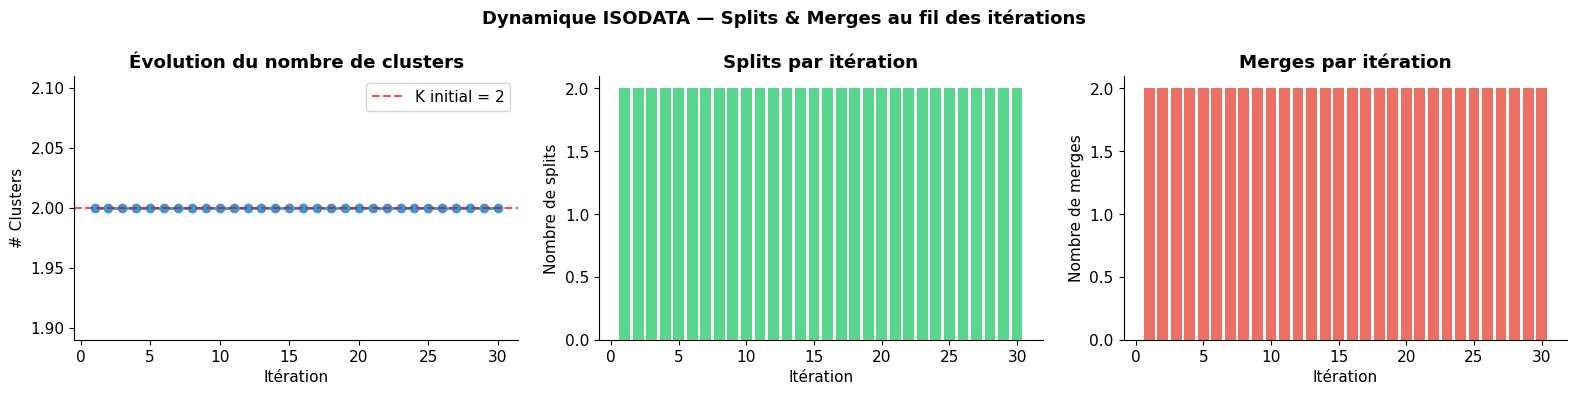

In [22]:
# Visualisation de l'évolution du nombre de clusters
history_df = pd.DataFrame(iso_model.history_)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df["iteration"], history_df["n_clusters"], 'o-', color="#3498db", linewidth=2)
axes[0].axhline(K_FINAL, color='red', linestyle='--', alpha=0.7, label=f'K initial = {K_FINAL}')
axes[0].set_title("Évolution du nombre de clusters", fontweight='bold')
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("# Clusters")
axes[0].legend()

axes[1].bar(history_df["iteration"], history_df["n_splits"], color="#2ecc71", alpha=0.8)
axes[1].set_title("Splits par itération", fontweight='bold')
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Nombre de splits")

axes[2].bar(history_df["iteration"], history_df["n_merges"], color="#e74c3c", alpha=0.8)
axes[2].set_title("Merges par itération", fontweight='bold')
axes[2].set_xlabel("Itération")
axes[2].set_ylabel("Nombre de merges")

plt.suptitle("Dynamique ISODATA — Splits & Merges au fil des itérations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [23]:
# Métriques ISODATA
iso_silhouette = silhouette_score(X_cluster, iso_labels)
iso_db         = davies_bouldin_score(X_cluster, iso_labels)
iso_ch         = calinski_harabasz_score(X_cluster, iso_labels)

print(f" ISODATA — K_final = {iso_model.n_clusters_}")
print(f"   Silhouette Score     : {iso_silhouette:.4f}")
print(f"   Davies-Bouldin Index : {iso_db:.4f}")
print(f"   Calinski-Harabasz    : {iso_ch:.4f}")

# Distribution des clusters
iso_sizes = pd.Series(iso_labels).value_counts().sort_index()
print(f"\n📊 Distribution des clusters ISODATA :")
for k, n in iso_sizes.items():
    print(f"   Cluster {k} : {n:>5} clients ({n/len(iso_labels)*100:.1f}%)")


 ISODATA — K_final = 2
   Silhouette Score     : 0.3172
   Davies-Bouldin Index : 1.9849
   Calinski-Harabasz    : 1504.8116

📊 Distribution des clusters ISODATA :
   Cluster 0 :  7068 clients (79.0%)
   Cluster 1 :  1882 clients (21.0%)


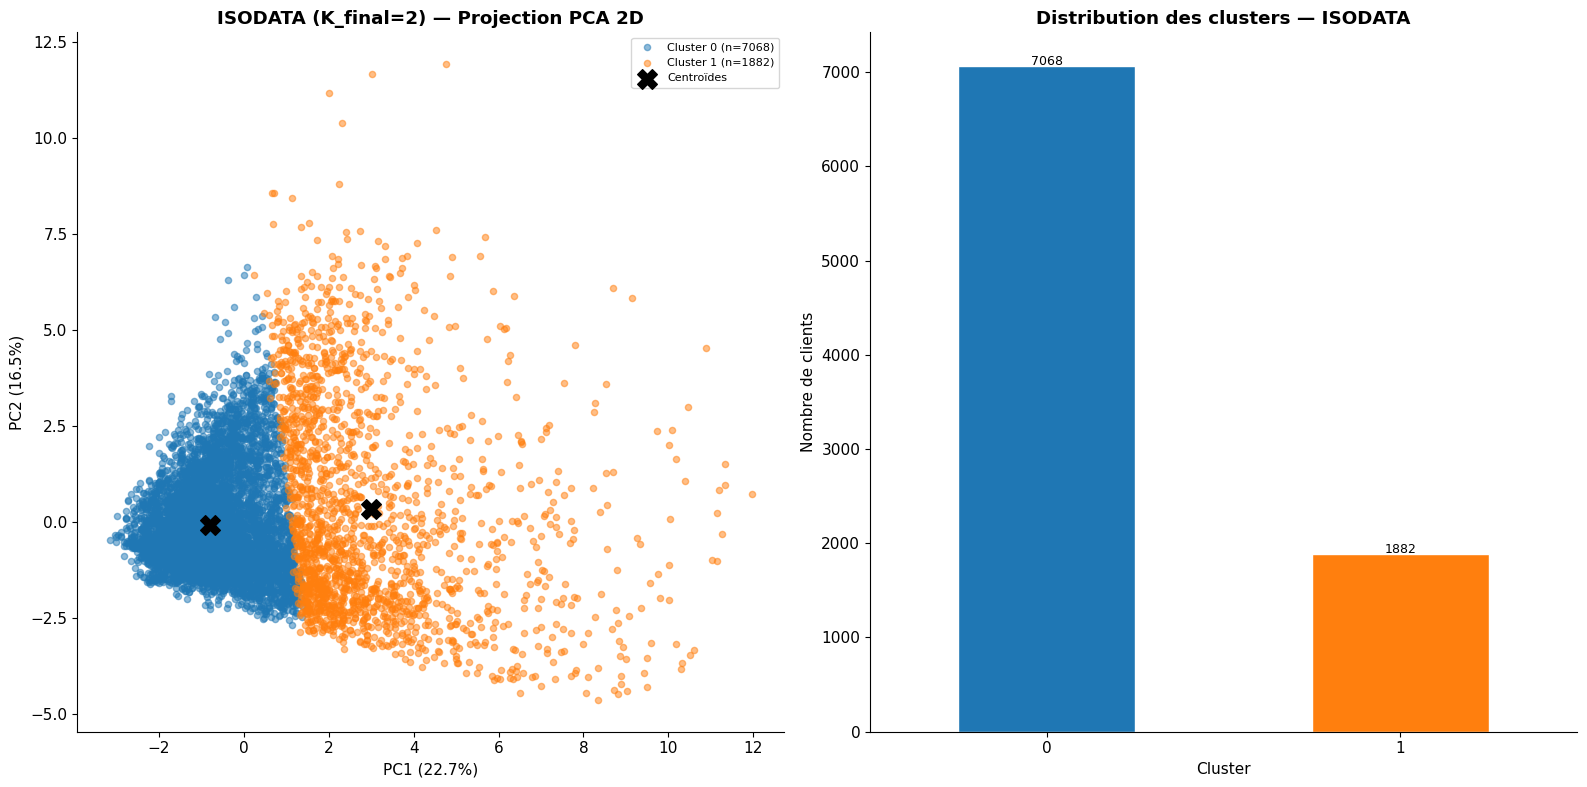

In [24]:
# Visualisation ISODATA sur PCA 2D
K_iso = iso_model.n_clusters_

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_L)

ax = axes[0]
for k in range(K_iso):
    mask = iso_labels == k
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               c=[PALETTE[k % 10]], label=f"Cluster {k} (n={mask.sum()})",
               alpha=0.5, s=20)
iso_centers_pca = pca_2d.transform(iso_model.centroids_)
ax.scatter(iso_centers_pca[:, 0], iso_centers_pca[:, 1], marker='X', s=200,
           c='black', zorder=5, label="Centroïdes")
ax.set_title(f"ISODATA (K_final={K_iso}) — Projection PCA 2D", fontweight='bold')
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(fontsize=8)

# Taille des clusters
ax = axes[1]
iso_sizes.plot(kind='bar', ax=ax, color=[PALETTE[k % 10] for k in iso_sizes.index],
               edgecolor='white')
ax.set_title("Distribution des clusters — ISODATA", fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Nombre de clients")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{int(bar.get_height())}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 9. Comparaison K-Means vs ISODATA

Comparaison empirique selon les métriques de clustering, la structure des clusters, et l'interprétabilité.


In [25]:
# Tableau de comparaison
comparison = pd.DataFrame({
    "Critère"              : ["# Clusters", "Silhouette ↑", "Davies-Bouldin ↓", "Calinski-Harabasz ↑"],
    "K-Means"              : [K_FINAL, f"{km_silhouette:.4f}", f"{km_db:.4f}", f"{km_ch:.1f}"],
    "ISODATA"              : [iso_model.n_clusters_, f"{iso_silhouette:.4f}", f"{iso_db:.4f}", f"{iso_ch:.1f}"],
    "Meilleur"             : [
        "ISODATA" if iso_model.n_clusters_ != K_FINAL else "=",
        "ISODATA" if iso_silhouette > km_silhouette else "K-Means",
        "ISODATA" if iso_db < km_db else "K-Means",
        "ISODATA" if iso_ch > km_ch else "K-Means",
    ]
})
print("📊 Comparaison empirique K-Means vs ISODATA :")
display(comparison)

# Analyse comparative
print("\n🔍 Analyse :")
if iso_silhouette > km_silhouette:
    print(f"   ISODATA produit des clusters plus cohérents et mieux séparés")
    print(f"      (Silhouette +{(iso_silhouette-km_silhouette):.4f})")
else:
    print(f"    K-Means produit un Silhouette légèrement meilleur — ISODATA peut nécessiter")
    print(f"      un ajustement des hyperparamètres (split_std, merge_dist)")

if iso_db < km_db:
    print(f"    ISODATA : meilleure séparation inter-cluster (DB plus bas)")
else:
    print(f"     K-Means : meilleur Davies-Bouldin")


📊 Comparaison empirique K-Means vs ISODATA :


,Critère,K-Means,ISODATA,Meilleur
0,# Clusters,2,2,=
1,Silhouette ↑,0.3172,0.3172,K-Means
2,Davies-Bouldin ↓,1.9851,1.9849,ISODATA
3,Calinski-Harabasz ↑,1504.8,1504.8,ISODATA



🔍 Analyse :
    K-Means produit un Silhouette légèrement meilleur — ISODATA peut nécessiter
      un ajustement des hyperparamètres (split_std, merge_dist)
    ISODATA : meilleure séparation inter-cluster (DB plus bas)


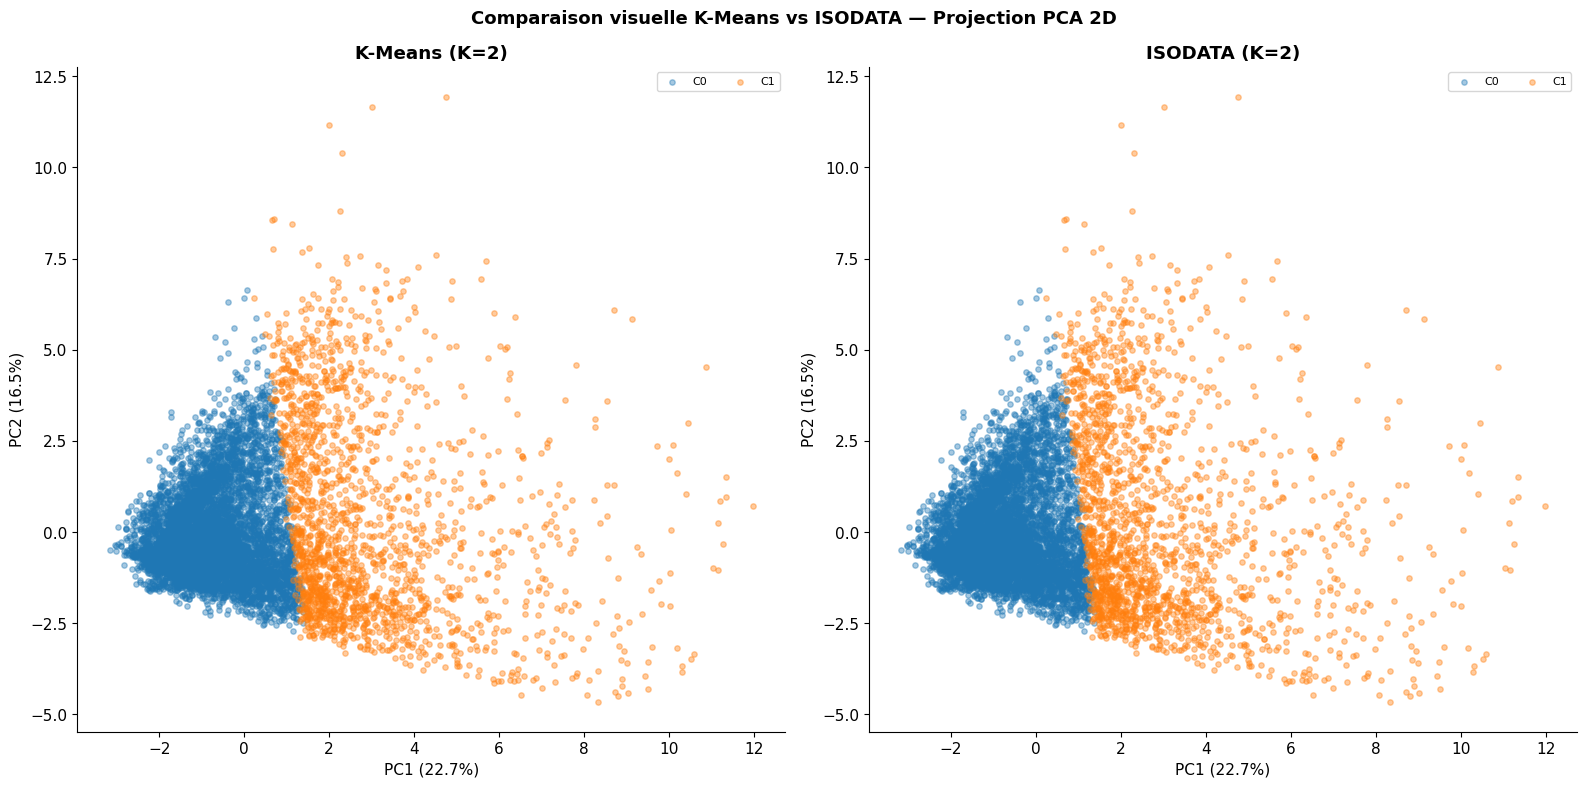

In [26]:
# Visualisation comparative côte à côte
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_L)

for ax, labels_plot, title, K in [
    (axes[0], km_labels,  f"K-Means (K={K_FINAL})", K_FINAL),
    (axes[1], iso_labels, f"ISODATA (K={iso_model.n_clusters_})", iso_model.n_clusters_)
]:
    for k in range(K):
        mask = labels_plot == k
        ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                   c=[PALETTE[k % 10]], alpha=0.4, s=15, label=f"C{k}")
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(fontsize=8, ncol=2)

plt.suptitle("Comparaison visuelle K-Means vs ISODATA — Projection PCA 2D",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10.  Interprétation Métier des Clusters

L'interprétation est l'étape **la plus importante** d'un projet de clustering.  
On passe des groupes mathématiques à des **segments clients actionnables**.


In [27]:
# Ajouter les labels ISODATA au dataframe original pour interprétation
df_result = df_fe.copy()
df_result["cluster_isodata"] = iso_labels
df_result["cluster_kmeans"]  = km_labels

# Profil de chaque cluster ISODATA
print("📊 Profil moyen par cluster ISODATA :")
cluster_profiles = df_result.groupby("cluster_isodata")[df_fe.columns].mean()
display(cluster_profiles.round(3))


📊 Profil moyen par cluster ISODATA :


,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_ONEOFF_RATIO,INSTALLMENT_DOMINANCE,CASH_ADVANCE_INTENSITY,PAYMENT_TO_CREDIT_RATIO,PAYMENT_TO_BALANCE_RATIO
cluster_isodata,,,,,,,,,,,,,,,,,
0,1072.353,0.854,444.523,220.596,658.504,0.123,7.852,3510.289,958.942,553.523,0.140,11.432,0.334,24.018,2962.119,0.384,106.053
1,3301.263,0.970,2782.871,1000.045,1977.783,0.502,37.809,8094.503,4242.568,1475.552,0.206,11.838,0.547,44.897,6865.732,0.713,118.956


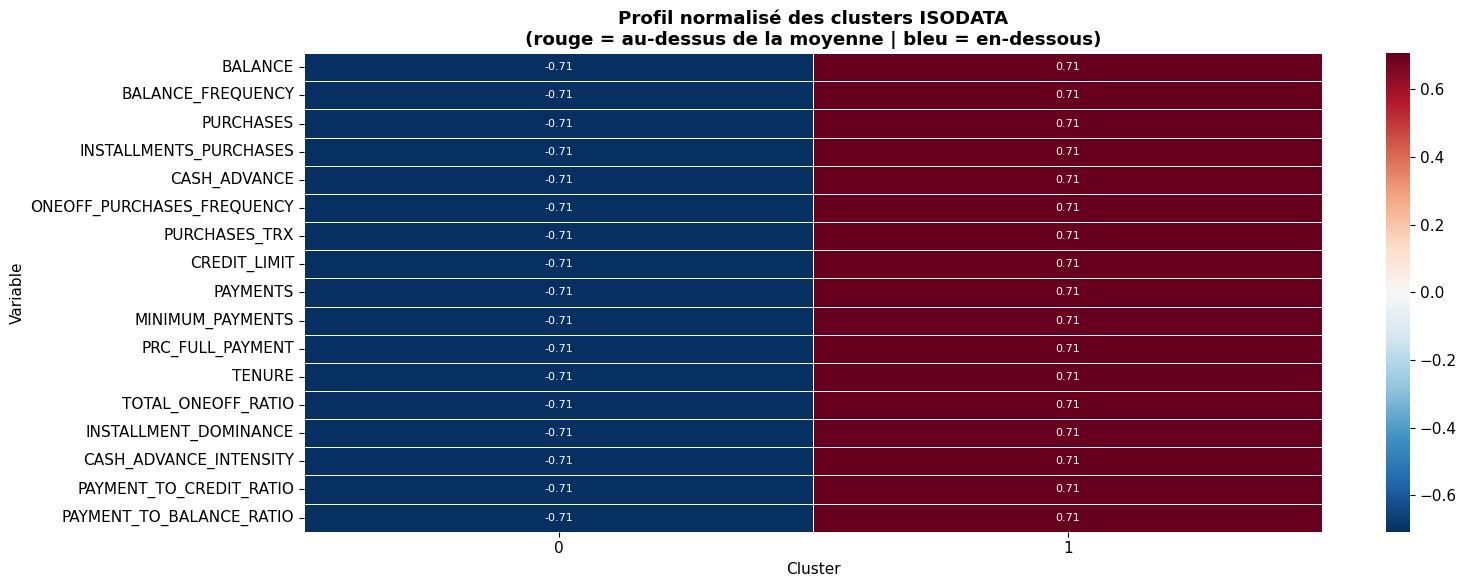

In [28]:
# ── Heatmap des profils normalisés par cluster ──────────────────────────────
profile_norm = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(profile_norm.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Profil normalisé des clusters ISODATA\n(rouge = au-dessus de la moyenne | bleu = en-dessous)",
             fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


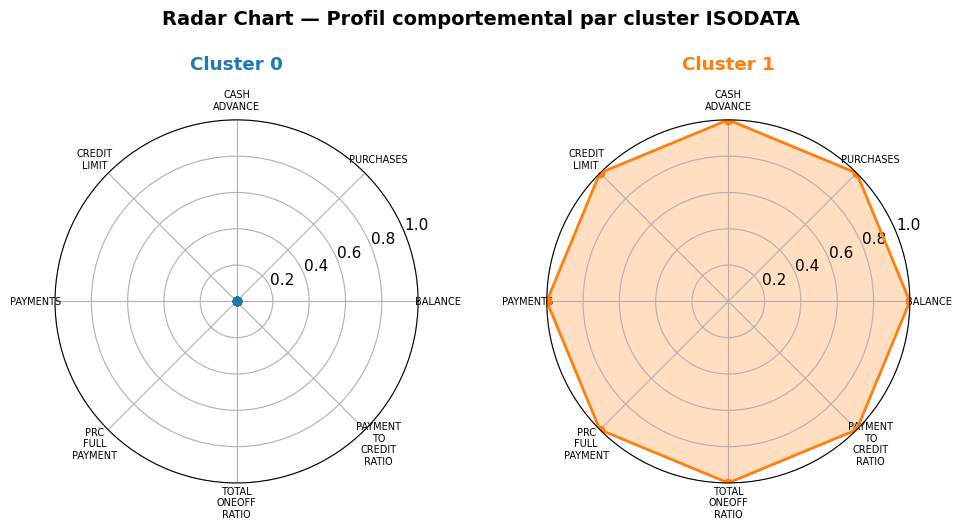

In [29]:
# ── Radar Chart (Spider Chart) par cluster ───────────────────────────────────
# Sélectionner les variables les plus discriminantes pour le radar
radar_vars = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
              "PAYMENTS", "PRC_FULL_PAYMENT", "TOTAL_ONEOFF_RATIO",
              "PAYMENT_TO_CREDIT_RATIO"]

# Normaliser entre 0 et 1 pour le radar
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
profile_radar = pd.DataFrame(
    mms.fit_transform(cluster_profiles[radar_vars]),
    index=cluster_profiles.index,
    columns=radar_vars
)

N    = len(radar_vars)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

n_clusters_iso = iso_model.n_clusters_
ncols = min(n_clusters_iso, 4)
nrows = (n_clusters_iso + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows),
                          subplot_kw=dict(polar=True))
if n_clusters_iso == 1:
    axes = [axes]
elif nrows == 1:
    axes = list(axes)
else:
    axes = [ax for row in axes for ax in row]

for idx, (cluster_id, row) in enumerate(profile_radar.iterrows()):
    ax = axes[idx]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=PALETTE[idx % 10])
    ax.fill(angles, values, alpha=0.25, color=PALETTE[idx % 10])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([v.replace("_", "\n") for v in radar_vars], size=7)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {cluster_id}", fontweight='bold', pad=15, color=PALETTE[idx % 10])

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Radar Chart — Profil comportemental par cluster ISODATA",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 10.1 Nommage Business des Segments Clients

>  **Note :** Les personas ci-dessous sont à adapter selon les valeurs réelles des profils de clusters calculés.  
> L'interprétation doit être relue à la lumière de la heatmap et du radar chart produits ci-dessus.

Les clusters typiquement observés sur ce dataset (CC-GENERAL) correspondent aux profils suivants :


In [30]:
# ── Attribution des personas basée sur le profil ───────────────────────────
# Critères d'identification automatique (adaptatif au nombre de clusters réel)

persona_rules = {
    "Acheteurs Actifs" : {
        "desc": "Fort volume d'achats, faible cash advance, remboursement correct",
        "signal_high": ["PURCHASES", "PURCHASES_TRX"],
        "signal_low" : ["CASH_ADVANCE", "BALANCE"]
    },
    "Utilisateurs Cash Advance" : {
        "desc": "Forte dépendance aux avances cash, faibles achats classiques",
        "signal_high": ["CASH_ADVANCE", "CASH_ADVANCE_INTENSITY"],
        "signal_low" : ["PURCHASES", "PRC_FULL_PAYMENT"]
    },
    " Clients Premium Solvables" : {
        "desc": "Limite de crédit élevée, remboursements complets, achats importants",
        "signal_high": ["CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"],
        "signal_low" : ["CASH_ADVANCE"]
    },
    "Clients Inactifs" : {
        "desc": "Faibles achats, faible balance, peu d'activité générale",
        "signal_high": [],
        "signal_low" : ["PURCHASES", "CASH_ADVANCE", "PAYMENTS"]
    },
    "Clients Crédit Échelonné" : {
        "desc": "Préférence pour les achats en plusieurs fois, remboursement partiel",
        "signal_high": ["INSTALLMENT_DOMINANCE", "INSTALLMENTS_PURCHASES"],
        "signal_low" : ["ONEOFFPURCHASES_FREQUENCY"]
    }
}

print("=" * 70)
print("  PERSONAS CLIENT — Segmentation ISODATA")
print("=" * 70)

for cluster_id in sorted(df_result["cluster_isodata"].unique()):
    profile = cluster_profiles.loc[cluster_id]
    n_clients = (df_result["cluster_isodata"] == cluster_id).sum()
    pct = n_clients / len(df_result) * 100

    print(f"\n{'─'*70}")
    print(f"CLUSTER {cluster_id}  |  {n_clients:,} clients ({pct:.1f}% du portefeuille)")
    print(f"{'─'*70}")
    print(f"  BALANCE moyen          : {profile.get('BALANCE', 0):>10,.2f}")
    print(f"  PURCHASES moyen        : {profile.get('PURCHASES', 0):>10,.2f}")
    print(f"  CASH_ADVANCE moyen     : {profile.get('CASH_ADVANCE', 0):>10,.2f}")
    print(f"  CREDIT_LIMIT moyen     : {profile.get('CREDIT_LIMIT', 0):>10,.2f}")
    print(f"  PAYMENTS moyen         : {profile.get('PAYMENTS', 0):>10,.2f}")
    print(f"  PRC_FULL_PAYMENT moyen : {profile.get('PRC_FULL_PAYMENT', 0):>10.3f}")
    print(f"  TOTAL_ONEOFF_RATIO     : {profile.get('TOTAL_ONEOFF_RATIO', 0):>10.3f}")


  PERSONAS CLIENT — Segmentation ISODATA

──────────────────────────────────────────────────────────────────────
CLUSTER 0  |  7,068 clients (79.0% du portefeuille)
──────────────────────────────────────────────────────────────────────
  BALANCE moyen          :   1,072.35
  PURCHASES moyen        :     444.52
  CASH_ADVANCE moyen     :     658.50
  CREDIT_LIMIT moyen     :   3,510.29
  PAYMENTS moyen         :     958.94
  PRC_FULL_PAYMENT moyen :      0.140
  TOTAL_ONEOFF_RATIO     :      0.334

──────────────────────────────────────────────────────────────────────
CLUSTER 1  |  1,882 clients (21.0% du portefeuille)
──────────────────────────────────────────────────────────────────────
  BALANCE moyen          :   3,301.26
  PURCHASES moyen        :   2,782.87
  CASH_ADVANCE moyen     :   1,977.78
  CREDIT_LIMIT moyen     :   8,094.50
  PAYMENTS moyen         :   4,242.57
  PRC_FULL_PAYMENT moyen :      0.206
  TOTAL_ONEOFF_RATIO     :      0.547


In [31]:
# ── Recommandations Marketing par Segment ─────────────────────────────────
recommandations = {
    "Clients à fort volume d'achats" : [
        "Programmes de fidélité et cashback sur les achats",
        "Upgrade vers une carte Premium avec avantages shopping",
        "Offres partenaires (e-commerce, retail)",
    ],
    "Utilisateurs Cash Advance" : [
        "Profil de risque élevé → surveillance de la solvabilité",
        "Contact proactif pour proposer des alternatives (crédit personnel)",
        "Limiter l'augmentation automatique de la limite de crédit",
    ],
    "Clients Premium Solvables" : [
        "Carte Platinum avec assurances voyages et conciergerie",
        "Augmentation proactive de la limite de crédit",
        "Offres de voyage et expériences premium",
    ],
    "Clients Inactifs" : [
        "Campagne de réactivation (offre bonus sur première transaction)",
        "Analyser les raisons d'inactivité (insatisfaction ? méconnaissance ?)",
        "Candidats à la fermeture de compte si inactivité persistante",
    ],
    "Clients Crédit Échelonné" : [
        "Offres de taux réduit sur les achats en plusieurs fois",
        "Éducation financière pour améliorer le taux de remboursement",
        "Produits de consolidation de dette",
    ]
}

print("=" * 70)
print("  RECOMMANDATIONS MARKETING PAR SEGMENT")
print("=" * 70)
for segment, actions in recommandations.items():
    print(f"\n {segment}")
    for action in actions:
        print(f"   {action}")


  RECOMMANDATIONS MARKETING PAR SEGMENT

 Clients à fort volume d'achats
   Programmes de fidélité et cashback sur les achats
   Upgrade vers une carte Premium avec avantages shopping
   Offres partenaires (e-commerce, retail)

 Utilisateurs Cash Advance
   Profil de risque élevé → surveillance de la solvabilité
   Contact proactif pour proposer des alternatives (crédit personnel)
   Limiter l'augmentation automatique de la limite de crédit

 Clients Premium Solvables
   Carte Platinum avec assurances voyages et conciergerie
   Augmentation proactive de la limite de crédit
   Offres de voyage et expériences premium

 Clients Inactifs
   Campagne de réactivation (offre bonus sur première transaction)
   Analyser les raisons d'inactivité (insatisfaction ? méconnaissance ?)
   Candidats à la fermeture de compte si inactivité persistante

 Clients Crédit Échelonné
   Offres de taux réduit sur les achats en plusieurs fois
   Éducation financière pour améliorer le taux de remboursement
   Pr

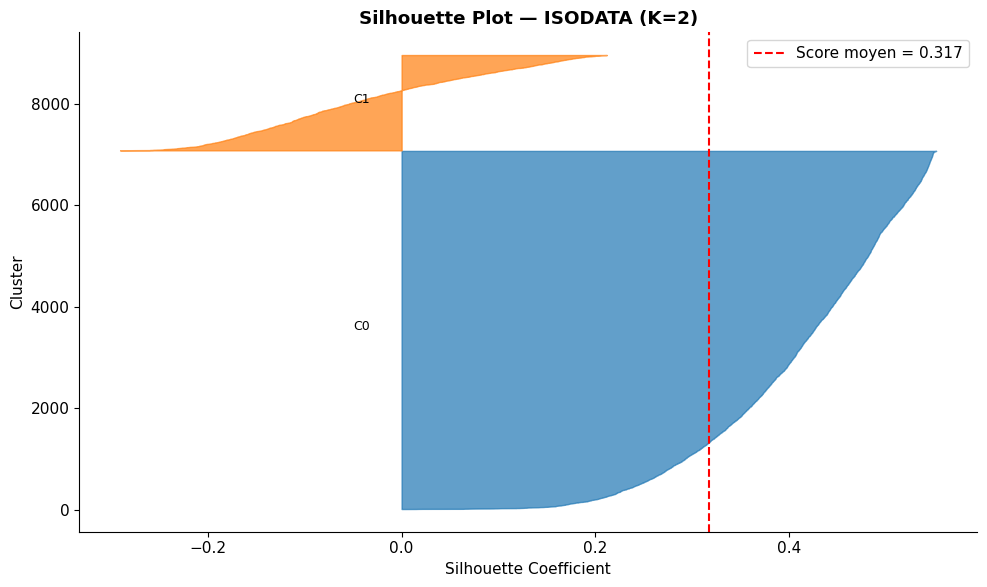


 Interprétation : Chaque bande = un cluster. Largeur = cohésion interne.
   Clusters bien formés : large, symétrique, au-dessus du score moyen (ligne rouge).


In [32]:
# ── Silhouette Plot détaillé par cluster ─────────────────────────────────
silhouette_vals = silhouette_samples(X_cluster, iso_labels)
K_iso = iso_model.n_clusters_

fig, ax = plt.subplots(figsize=(10, max(6, K_iso)))
y_lower = 10

for k in range(K_iso):
    cluster_sil = np.sort(silhouette_vals[iso_labels == k])
    size_k = cluster_sil.shape[0]
    y_upper = y_lower + size_k

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=PALETTE[k % 10], edgecolor=PALETTE[k % 10], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_k, f"C{k}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(iso_silhouette, color="red", linestyle="--", label=f"Score moyen = {iso_silhouette:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — ISODATA (K={K_iso})", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print("\n Interprétation : Chaque bande = un cluster. Largeur = cohésion interne.")
print("   Clusters bien formés : large, symétrique, au-dessus du score moyen (ligne rouge).")
